<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Brilho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import f_oneway
from google.colab import files  # Para upload de arquivos no Colab

In [ ]:
# Configurando o estilo dos gráficos
sns.set(style="whitegrid")

# Upload do arquivo
print("Por favor, faça o upload da planilha contendo os dados do experimento (formato .csv ou .xlsx).")
uploaded = files.upload()  # Permite o upload do arquivo

# Identificando o arquivo carregado
for filename in uploaded.keys():
    print(f"Arquivo carregado: {filename}")

# Verificando o formato do arquivo e carregando os dados
if filename.endswith('.csv'):
    df = pd.read_csv(filename)
elif filename.endswith('.xlsx'):
    df = pd.read_excel(filename)
else:
    raise ValueError("Formato de arquivo não suportado. Por favor, use .csv ou .xlsx.")

# Verificando as colunas disponíveis
print("\nColunas disponíveis no arquivo:")
print(df.columns)

Por favor, faça o upload da planilha contendo os dados do experimento (formato .csv ou .xlsx).


Saving brilho.xlsx to brilho.xlsx
Arquivo carregado: brilho.xlsx

Colunas disponíveis no arquivo:
Index(['- Leave in + Mascara', 'Gb 3025 / GB 3024', 'Concentração',
       'Soma de BNT', 'Soma de ReichRobbins', 'Soma de Guiolet',
       'Soma de Spec_Int', 'Soma de Spec_Theta', 'Soma de Spec_W_visual',
       'Soma de Spec_Max', 'Soma de Spec_Center', 'Soma de Shine_Int',
       'Soma de Shine_Theta', 'Soma de Shine_Max', 'Soma de Shine_Center',
       'Soma de Chroma_Int', 'Soma de Chroma_Theta', 'Soma de Chroma_Max',
       'Soma de Chroma_Center', 'Soma de Diff_Max', 'Soma de Diff_Int',
       'Soma de Shine_Visibility', 'Soma de Chroma_Visibility'],
      dtype='object')


In [ ]:
# Solicitando ao usuário a quantidade de fatores e respostas
num_fatores = int(input("\nQuantos fatores você deseja analisar? "))
num_respostas = int(input("Quantas respostas você deseja analisar? "))

# Assumindo que os fatores estão nas primeiras colunas e as respostas nas colunas seguintes
fatores = df.columns[:num_fatores].tolist()
respostas = df.columns[num_fatores:num_fatores + num_respostas].tolist()

# Exibindo os fatores e respostas identificados
print("\nFatores identificados:", fatores)
print("Respostas identificadas:", respostas)



Quantos fatores você deseja analisar? 3
Quantas respostas você deseja analisar? 20

Fatores identificados: ['- Leave in + Mascara', 'Gb 3025 / GB 3024', 'Concentração']
Respostas identificadas: ['Soma de BNT', 'Soma de ReichRobbins', 'Soma de Guiolet', 'Soma de Spec_Int', 'Soma de Spec_Theta', 'Soma de Spec_W_visual', 'Soma de Spec_Max', 'Soma de Spec_Center', 'Soma de Shine_Int', 'Soma de Shine_Theta', 'Soma de Shine_Max', 'Soma de Shine_Center', 'Soma de Chroma_Int', 'Soma de Chroma_Theta', 'Soma de Chroma_Max', 'Soma de Chroma_Center', 'Soma de Diff_Max', 'Soma de Diff_Int', 'Soma de Shine_Visibility', 'Soma de Chroma_Visibility']


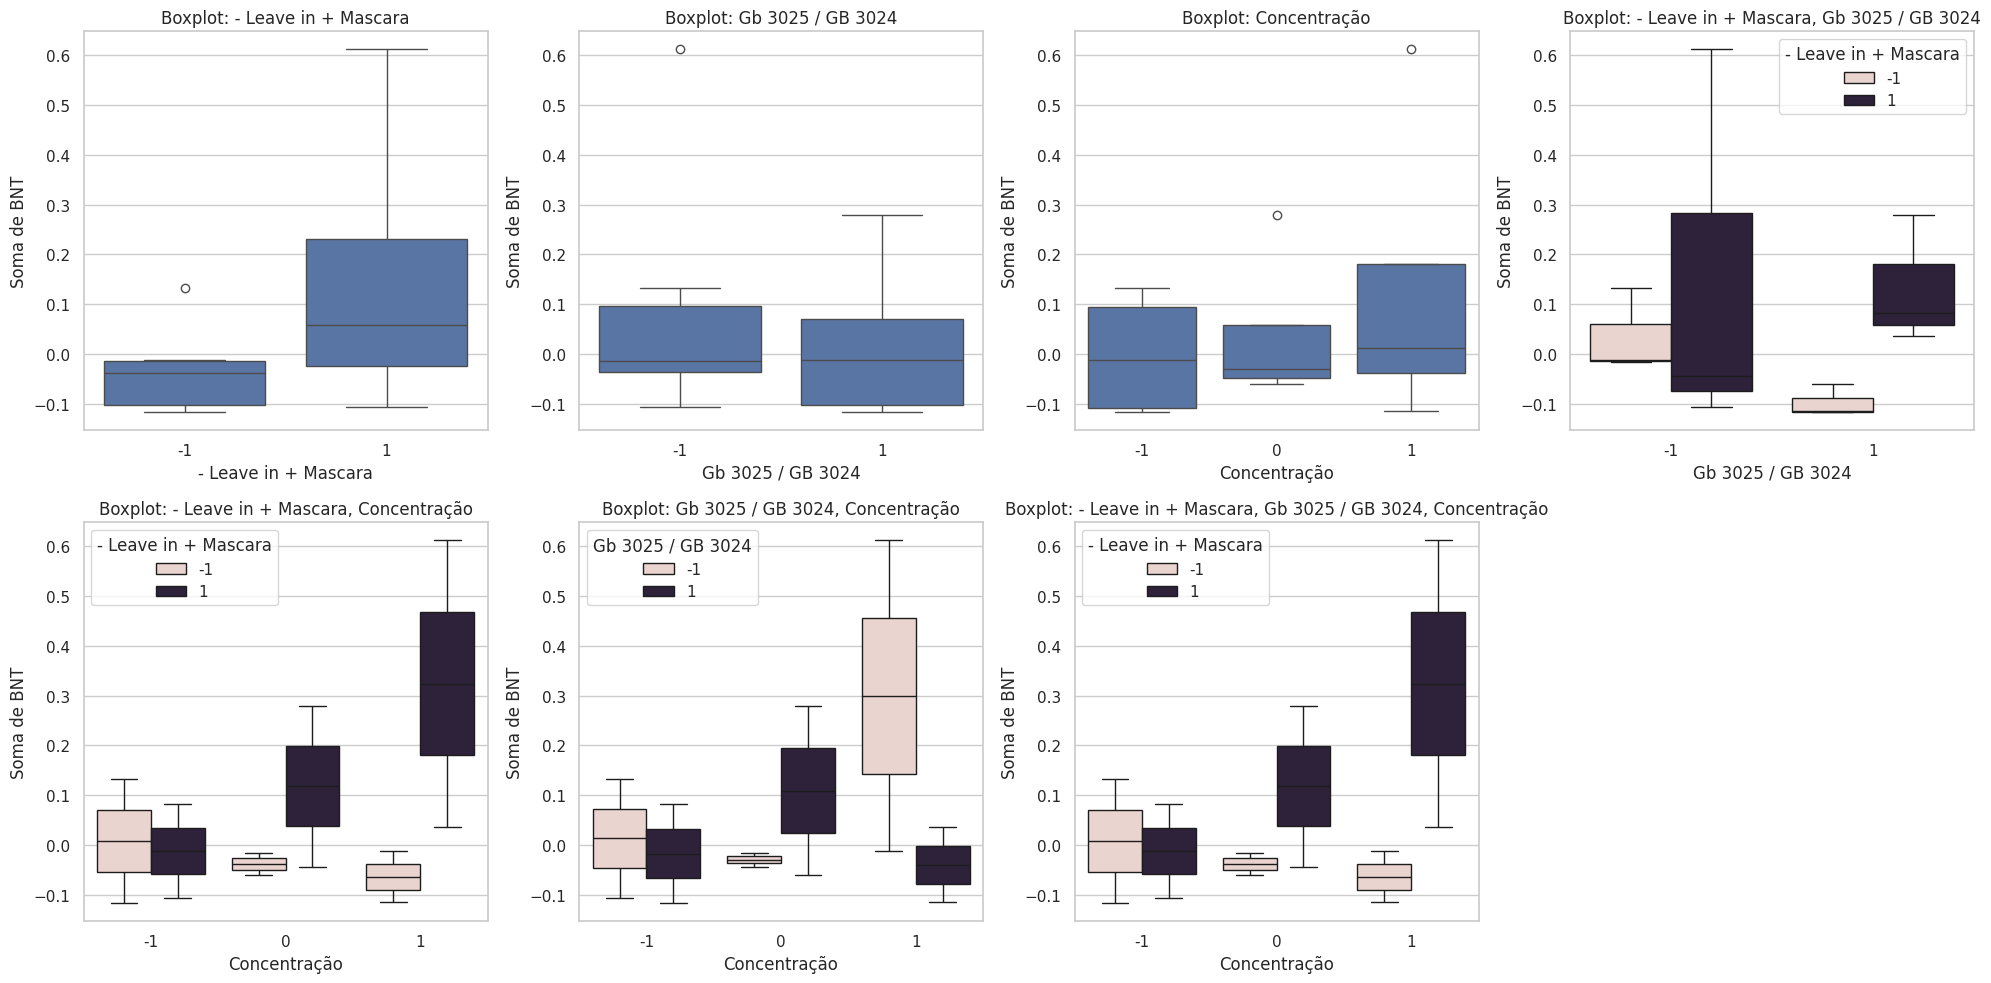

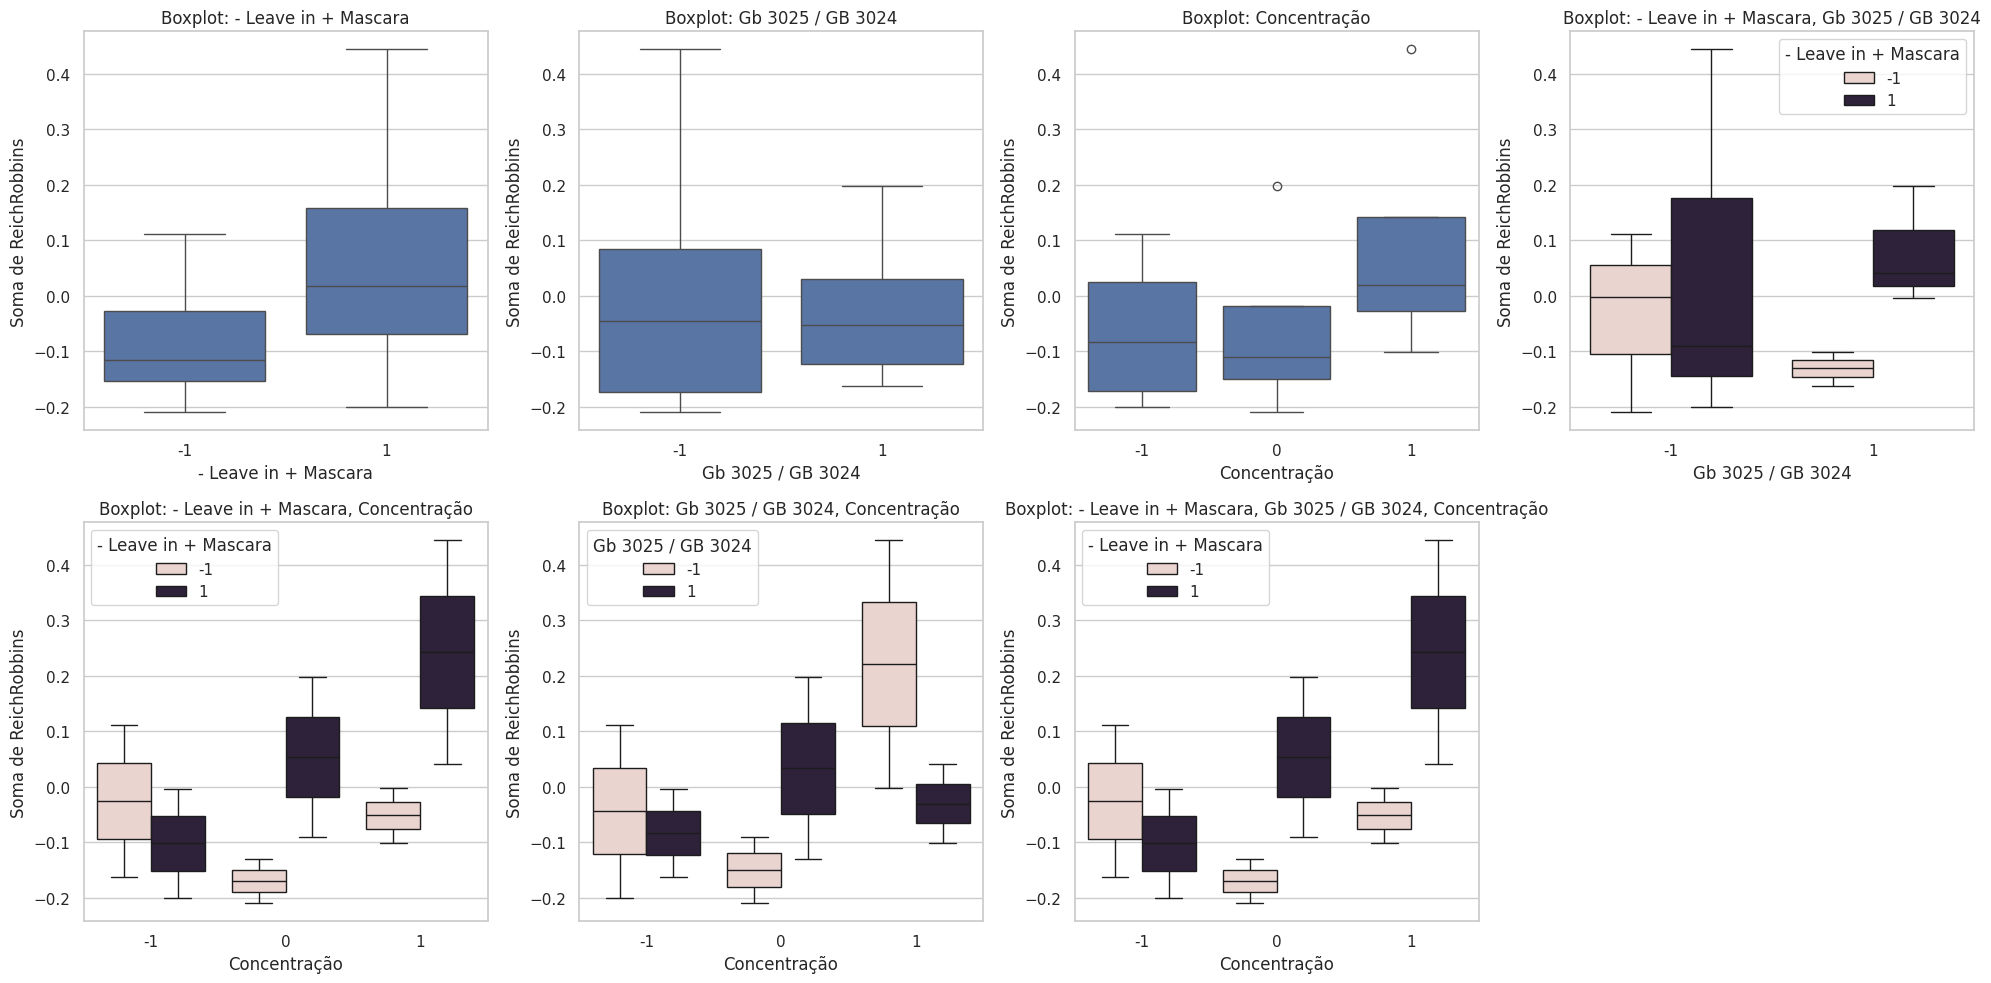

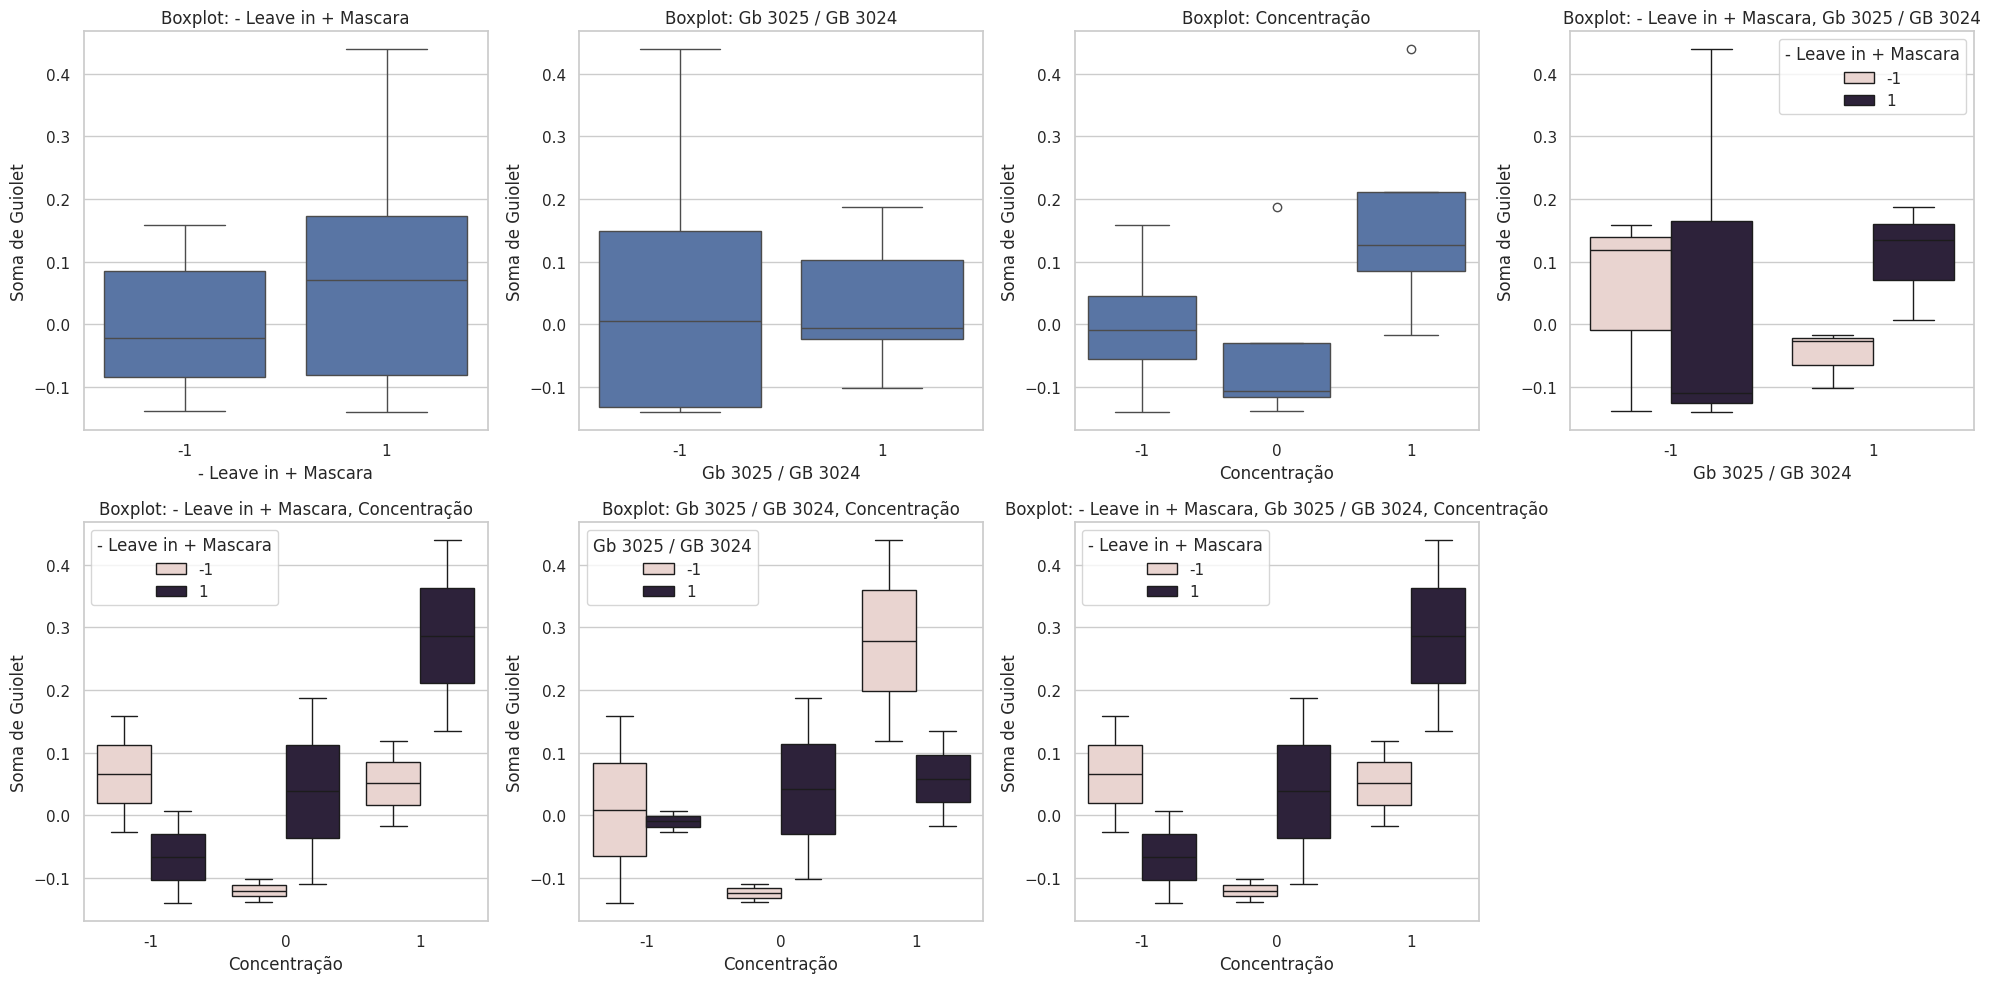

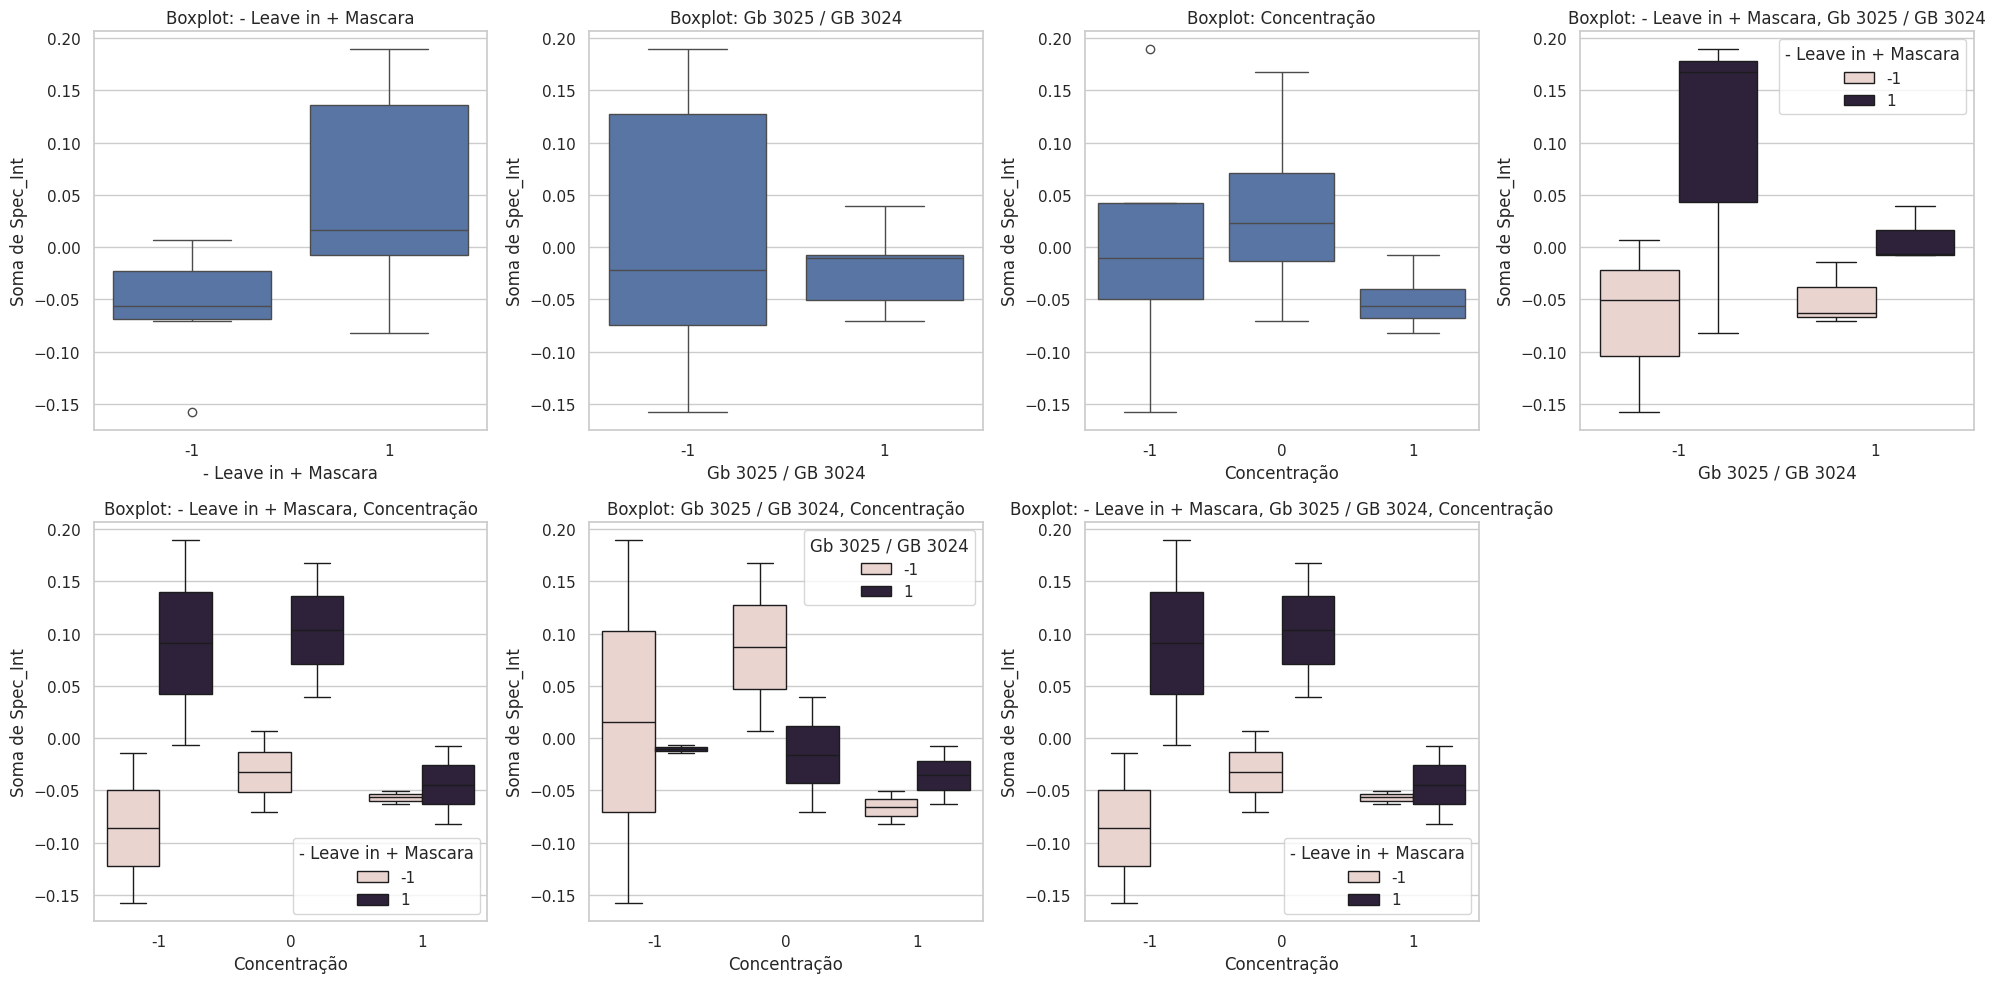

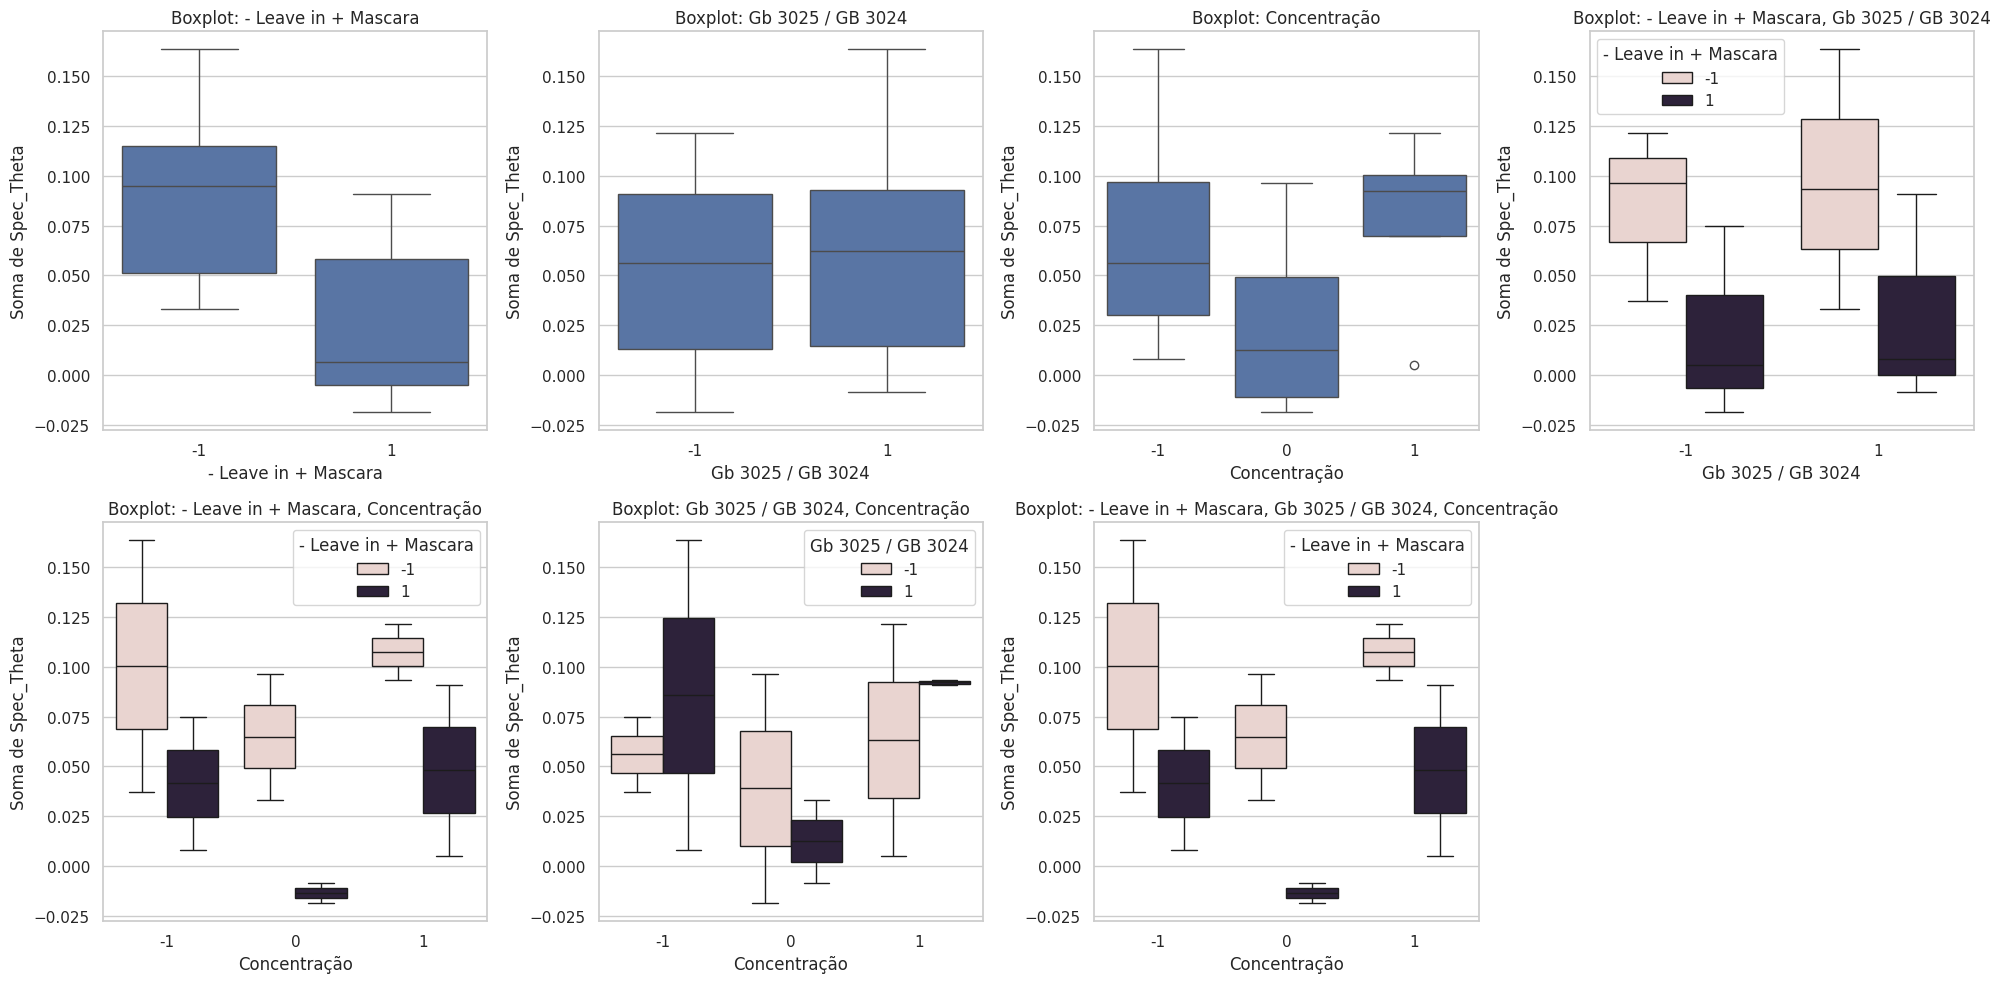

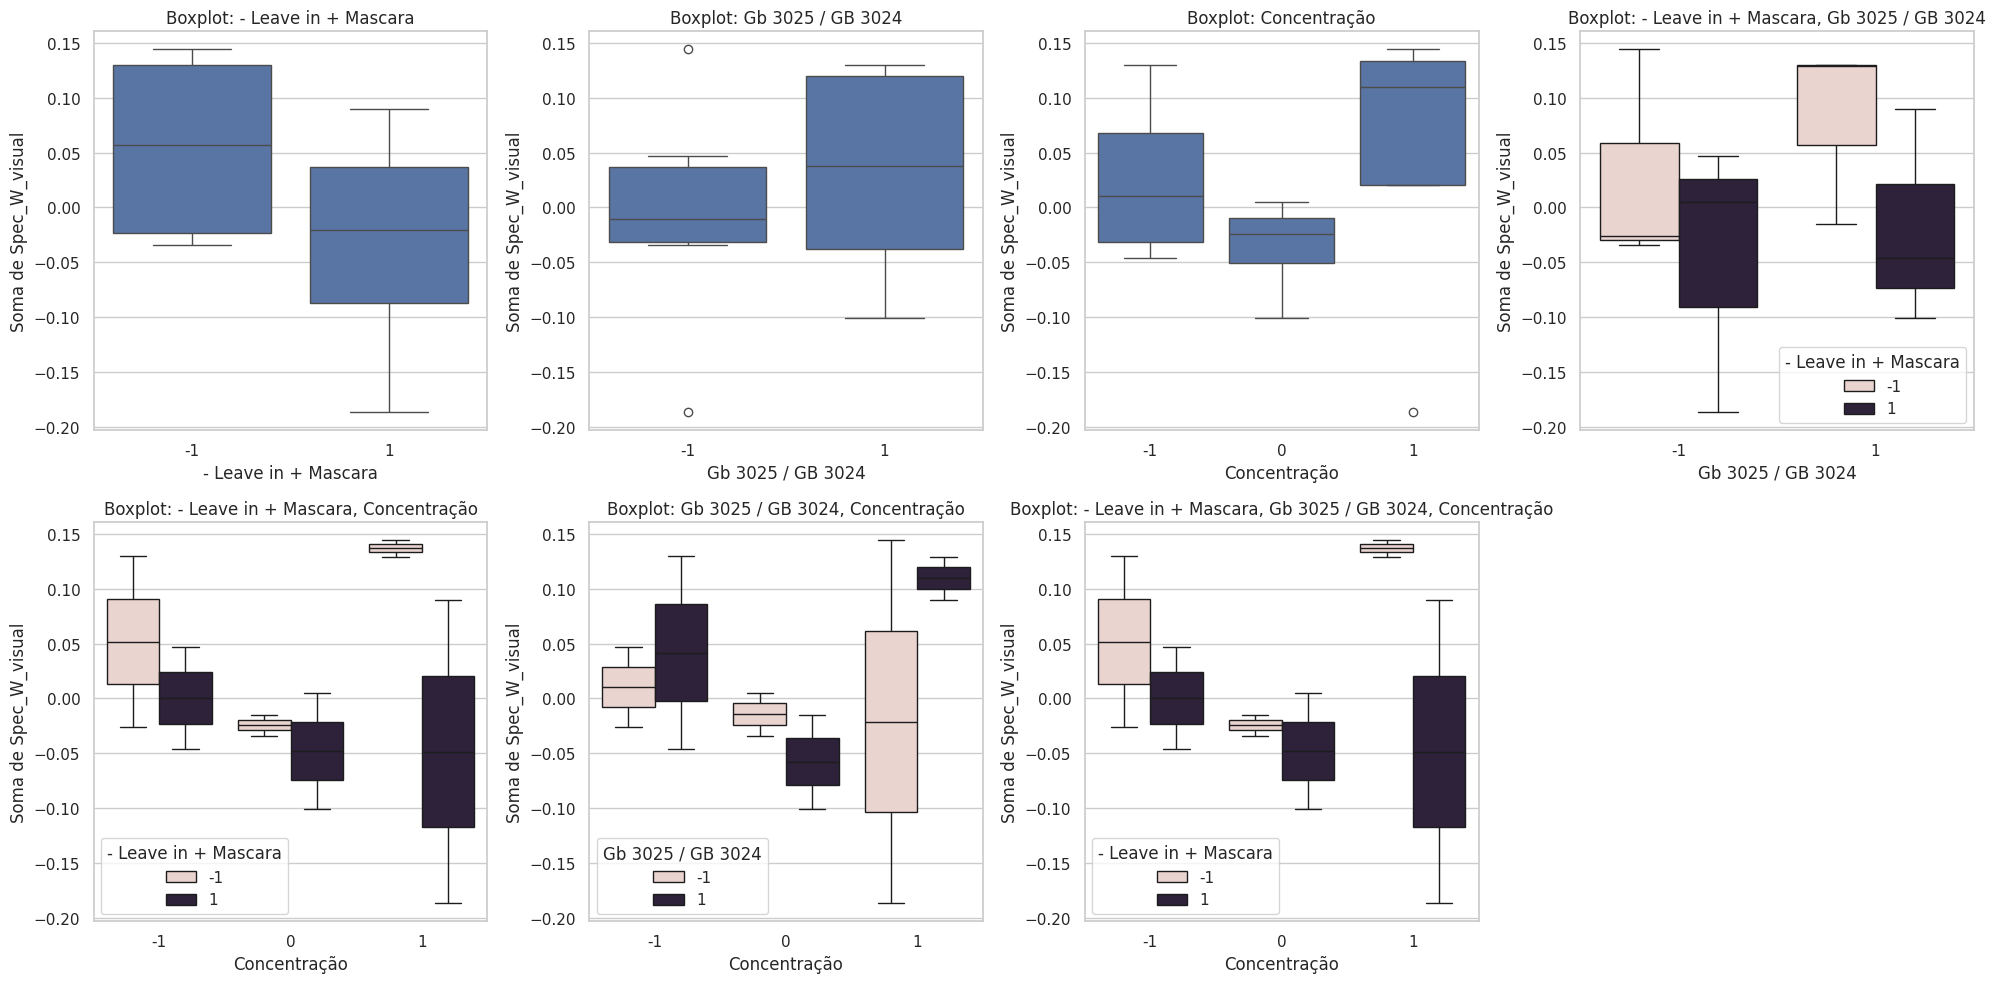

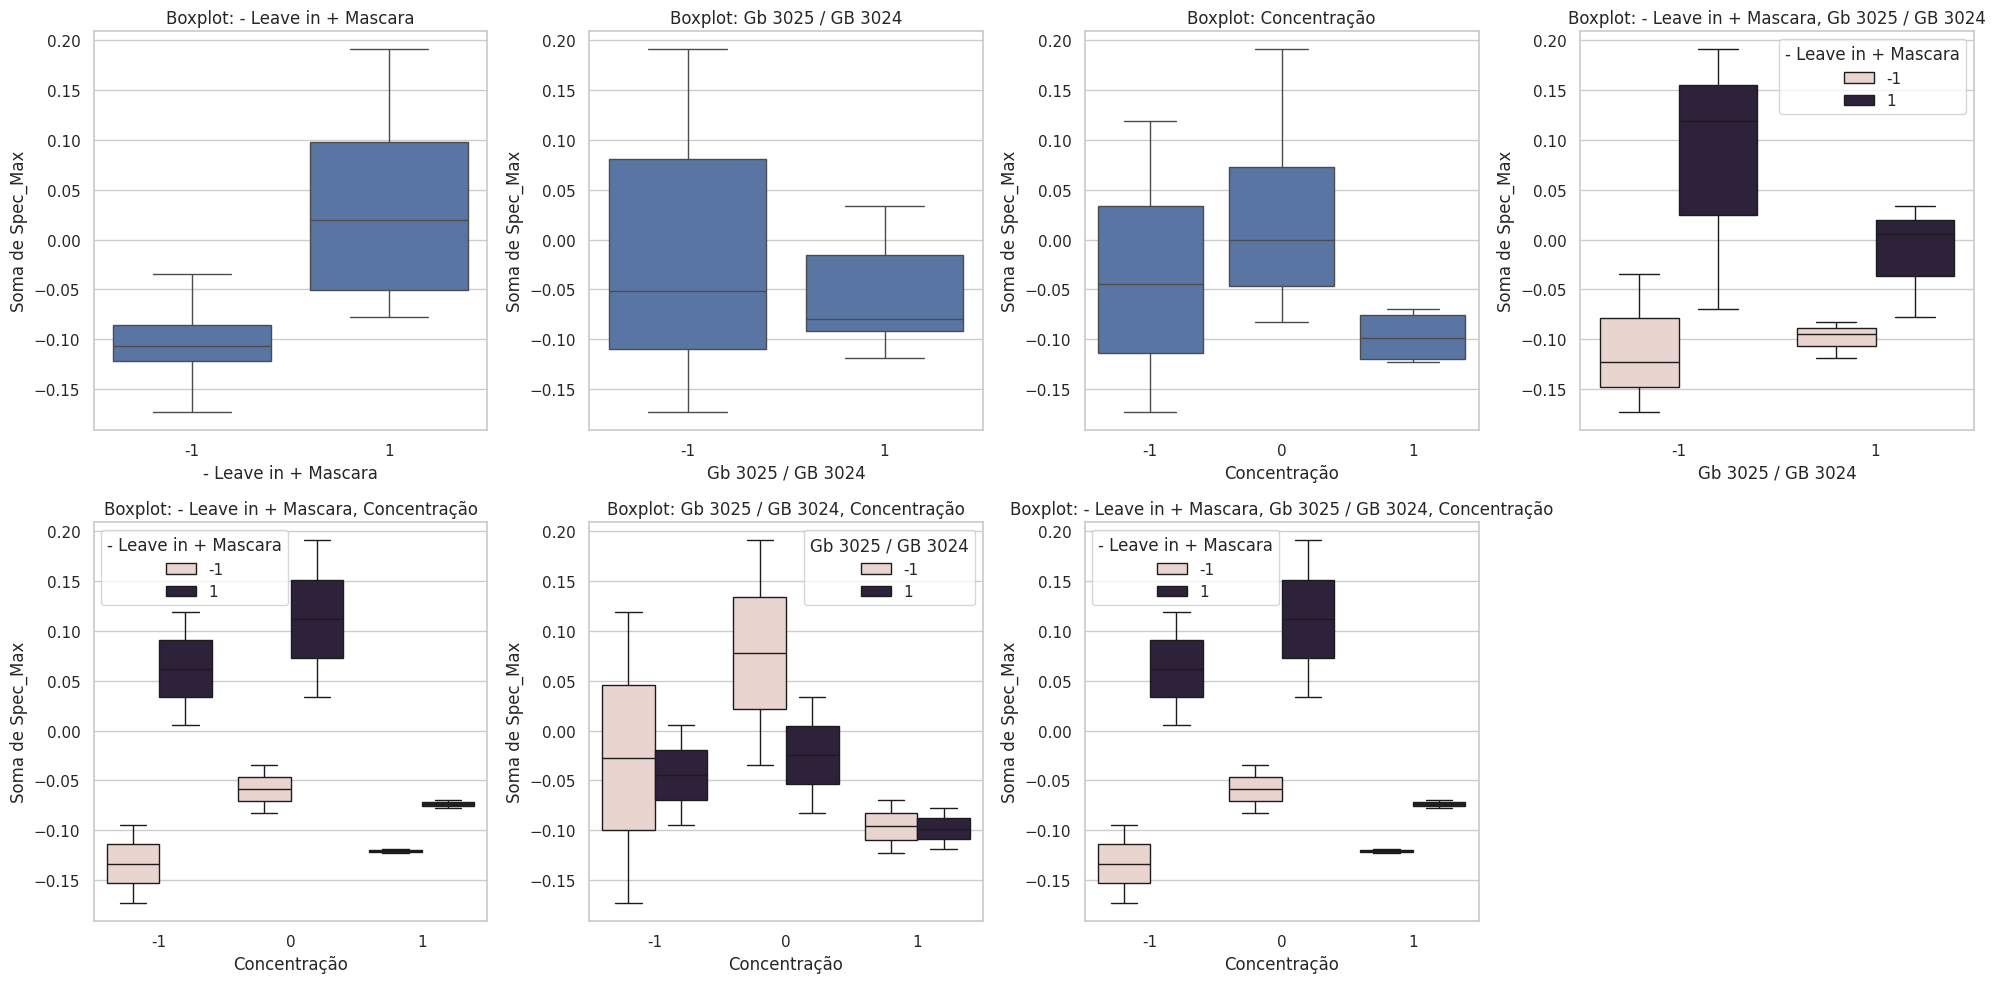

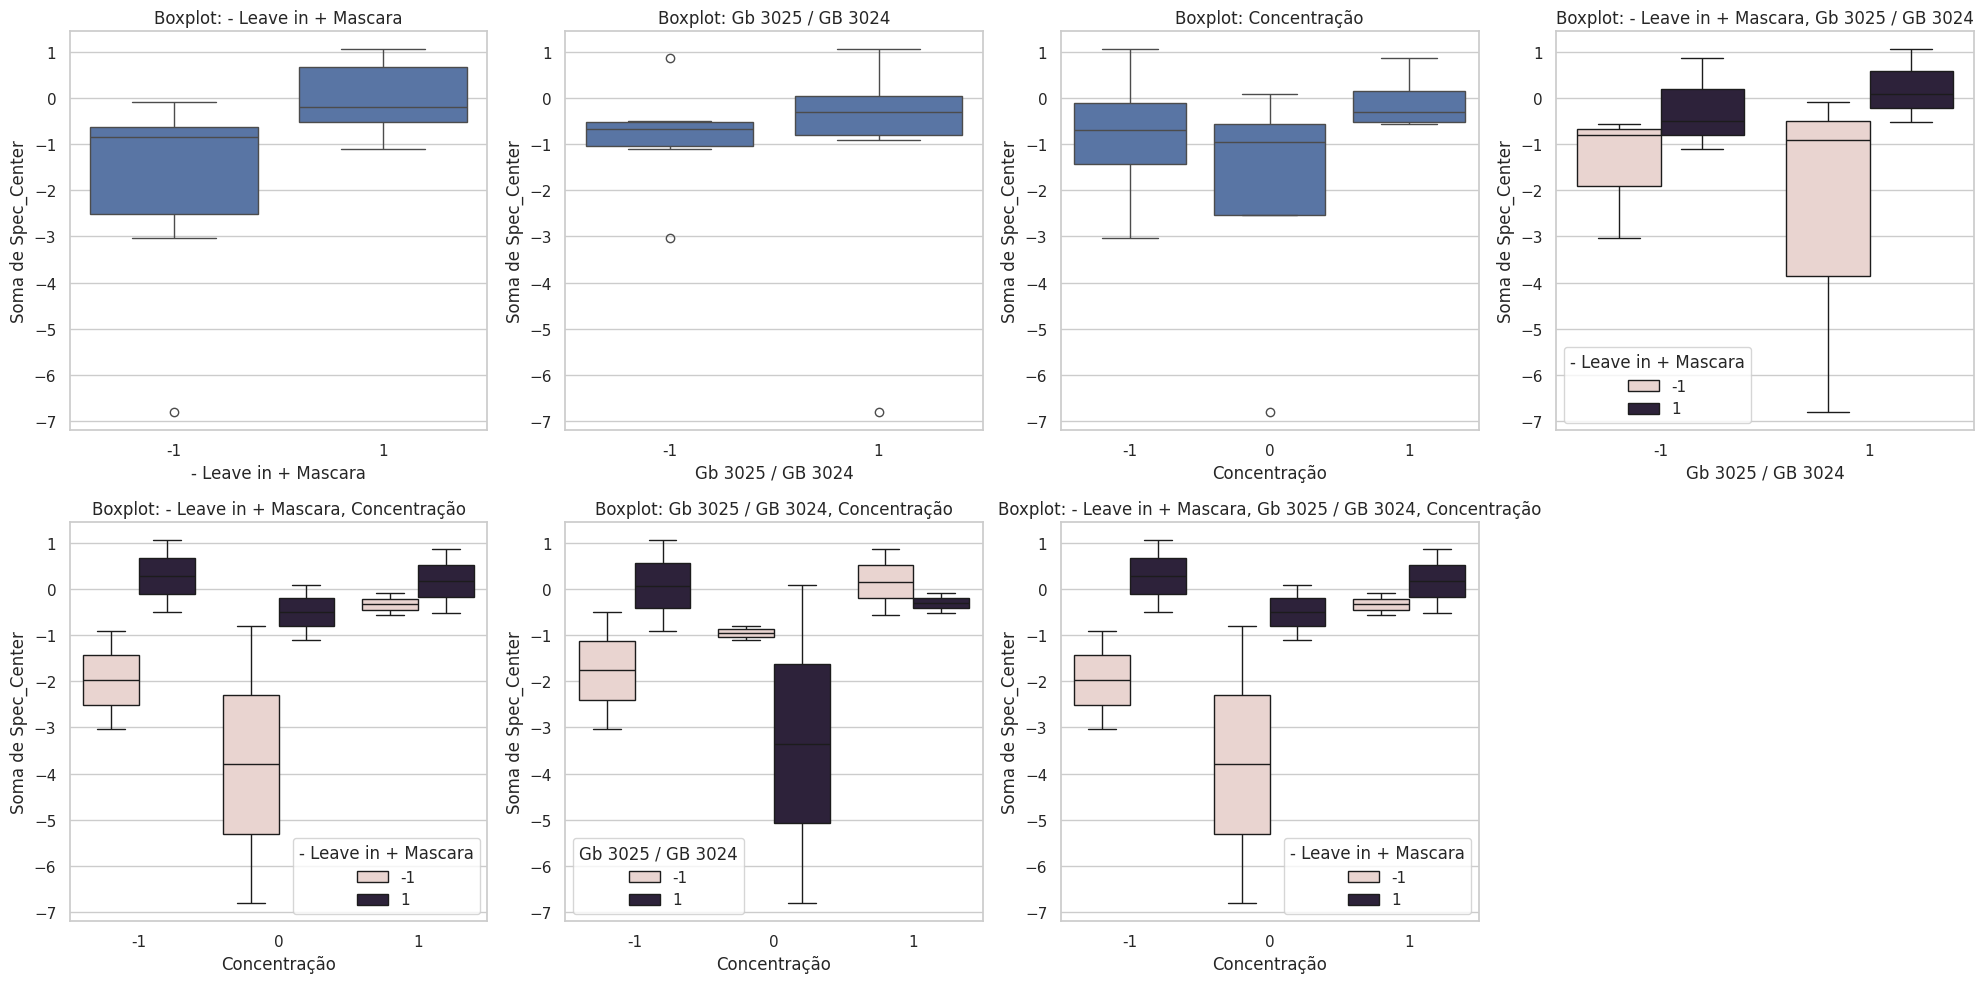

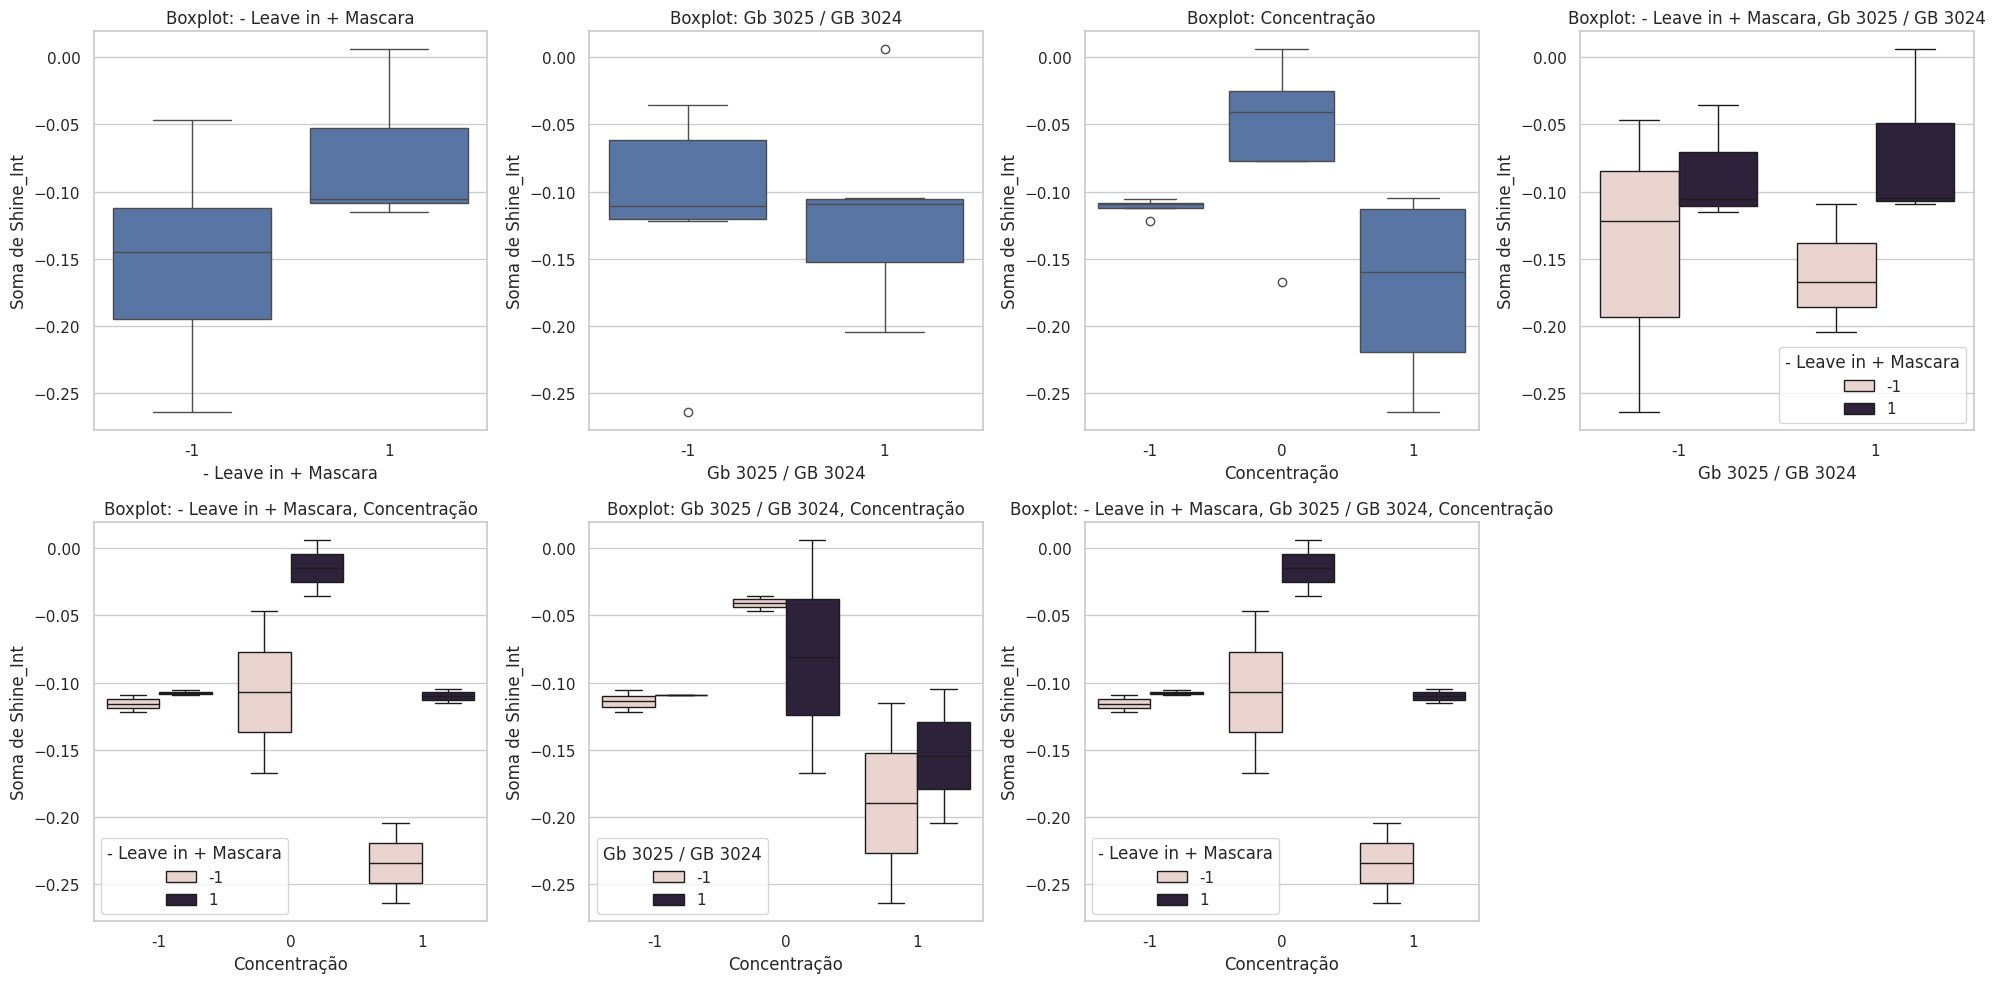

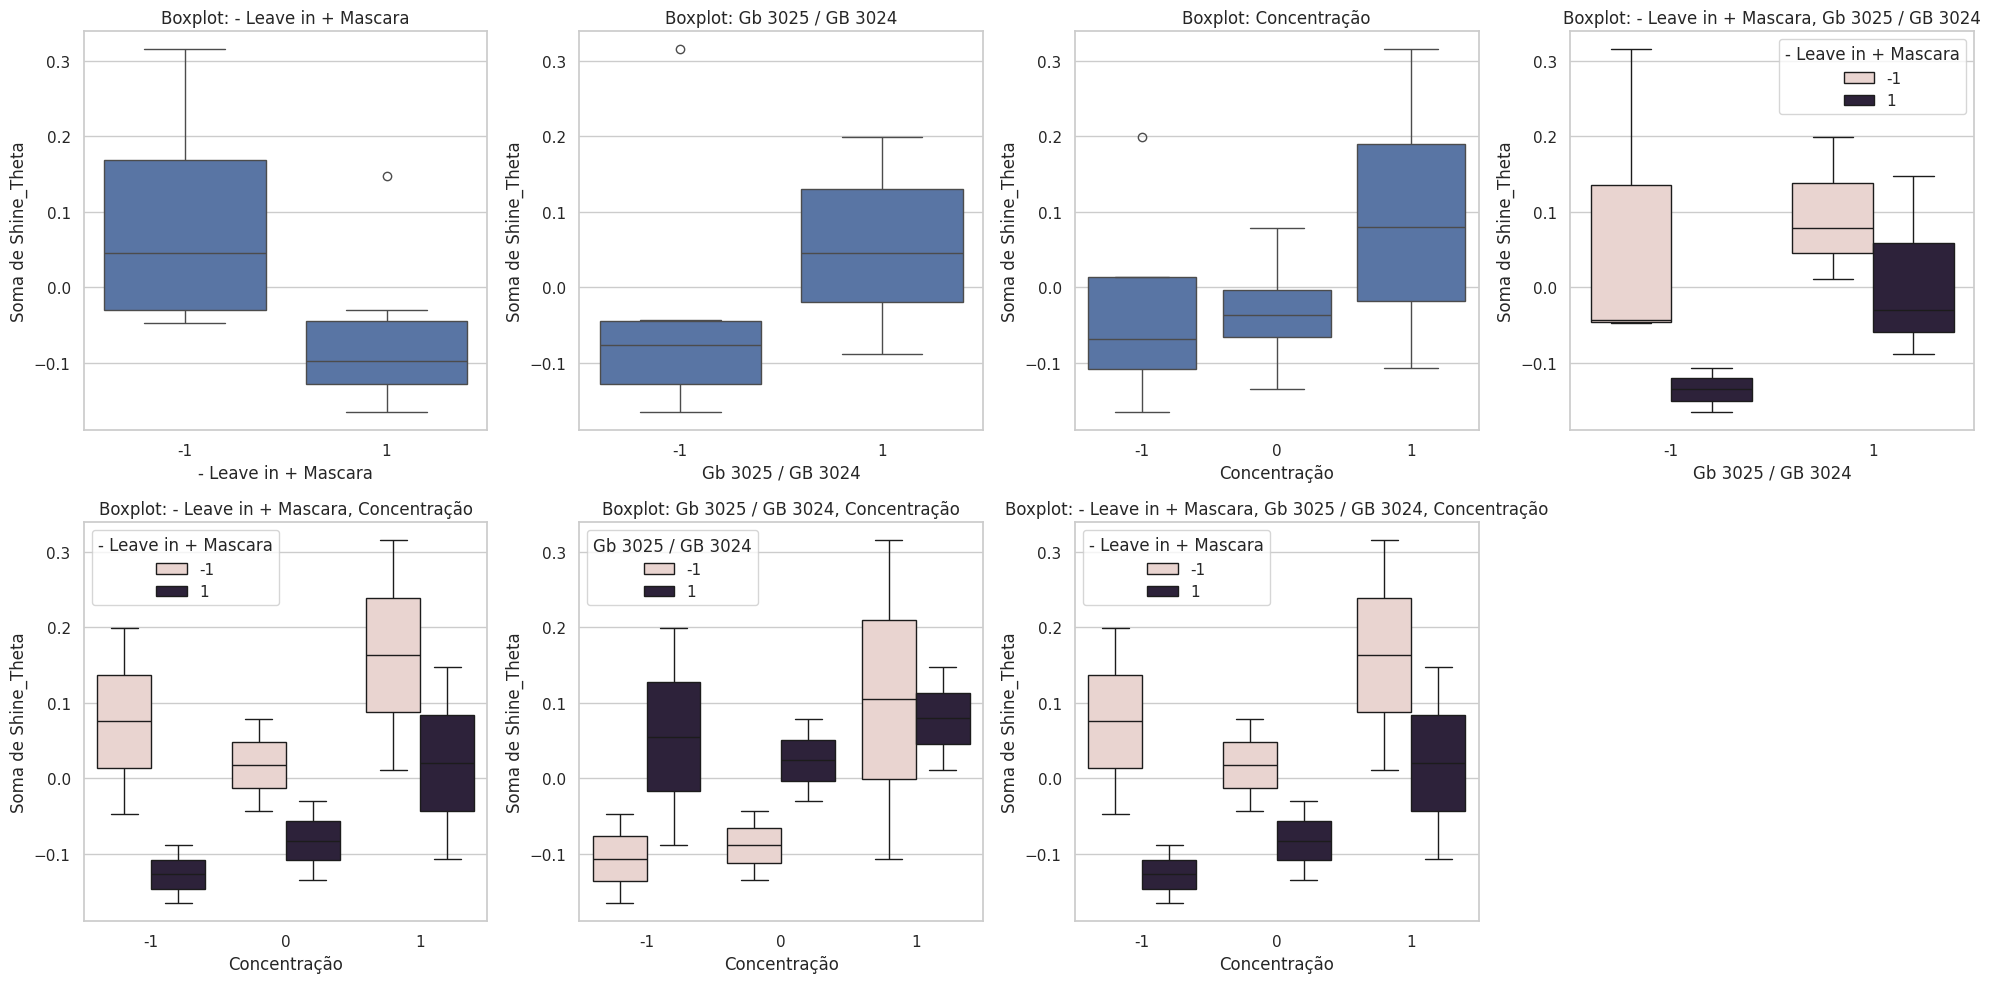

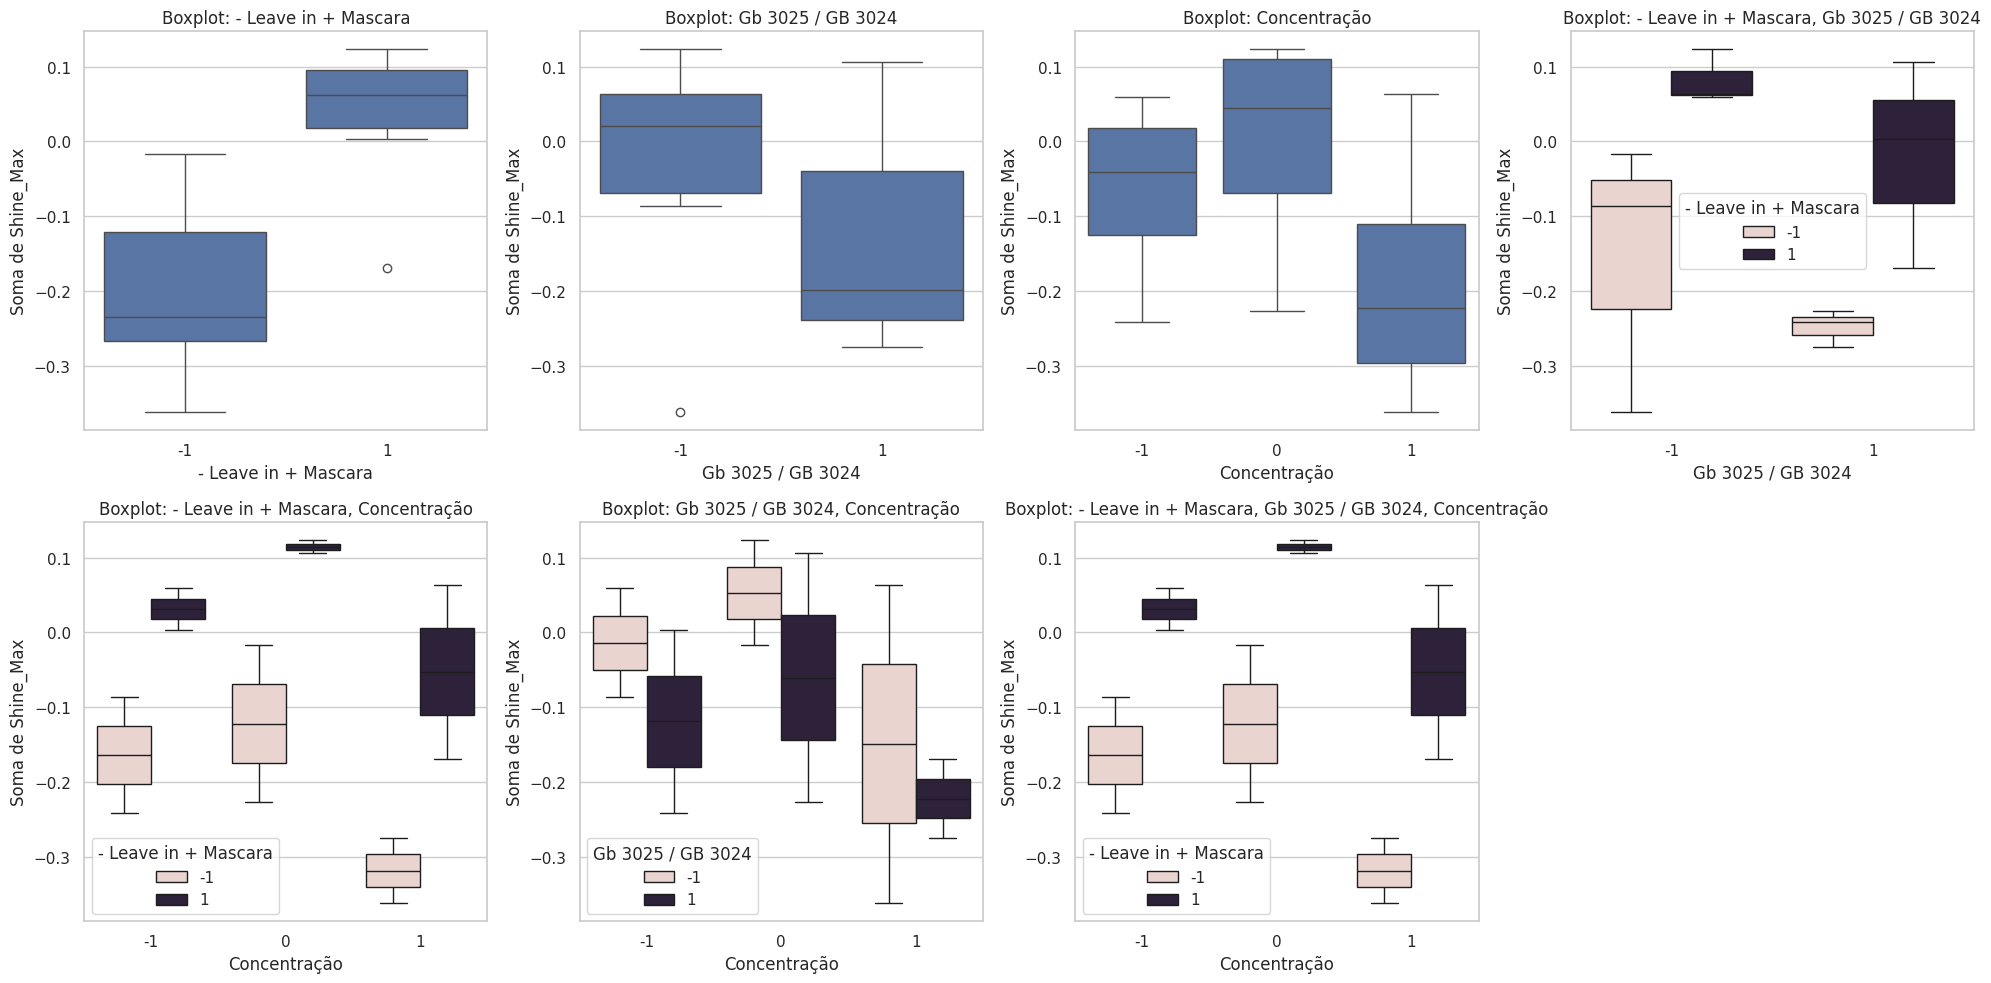

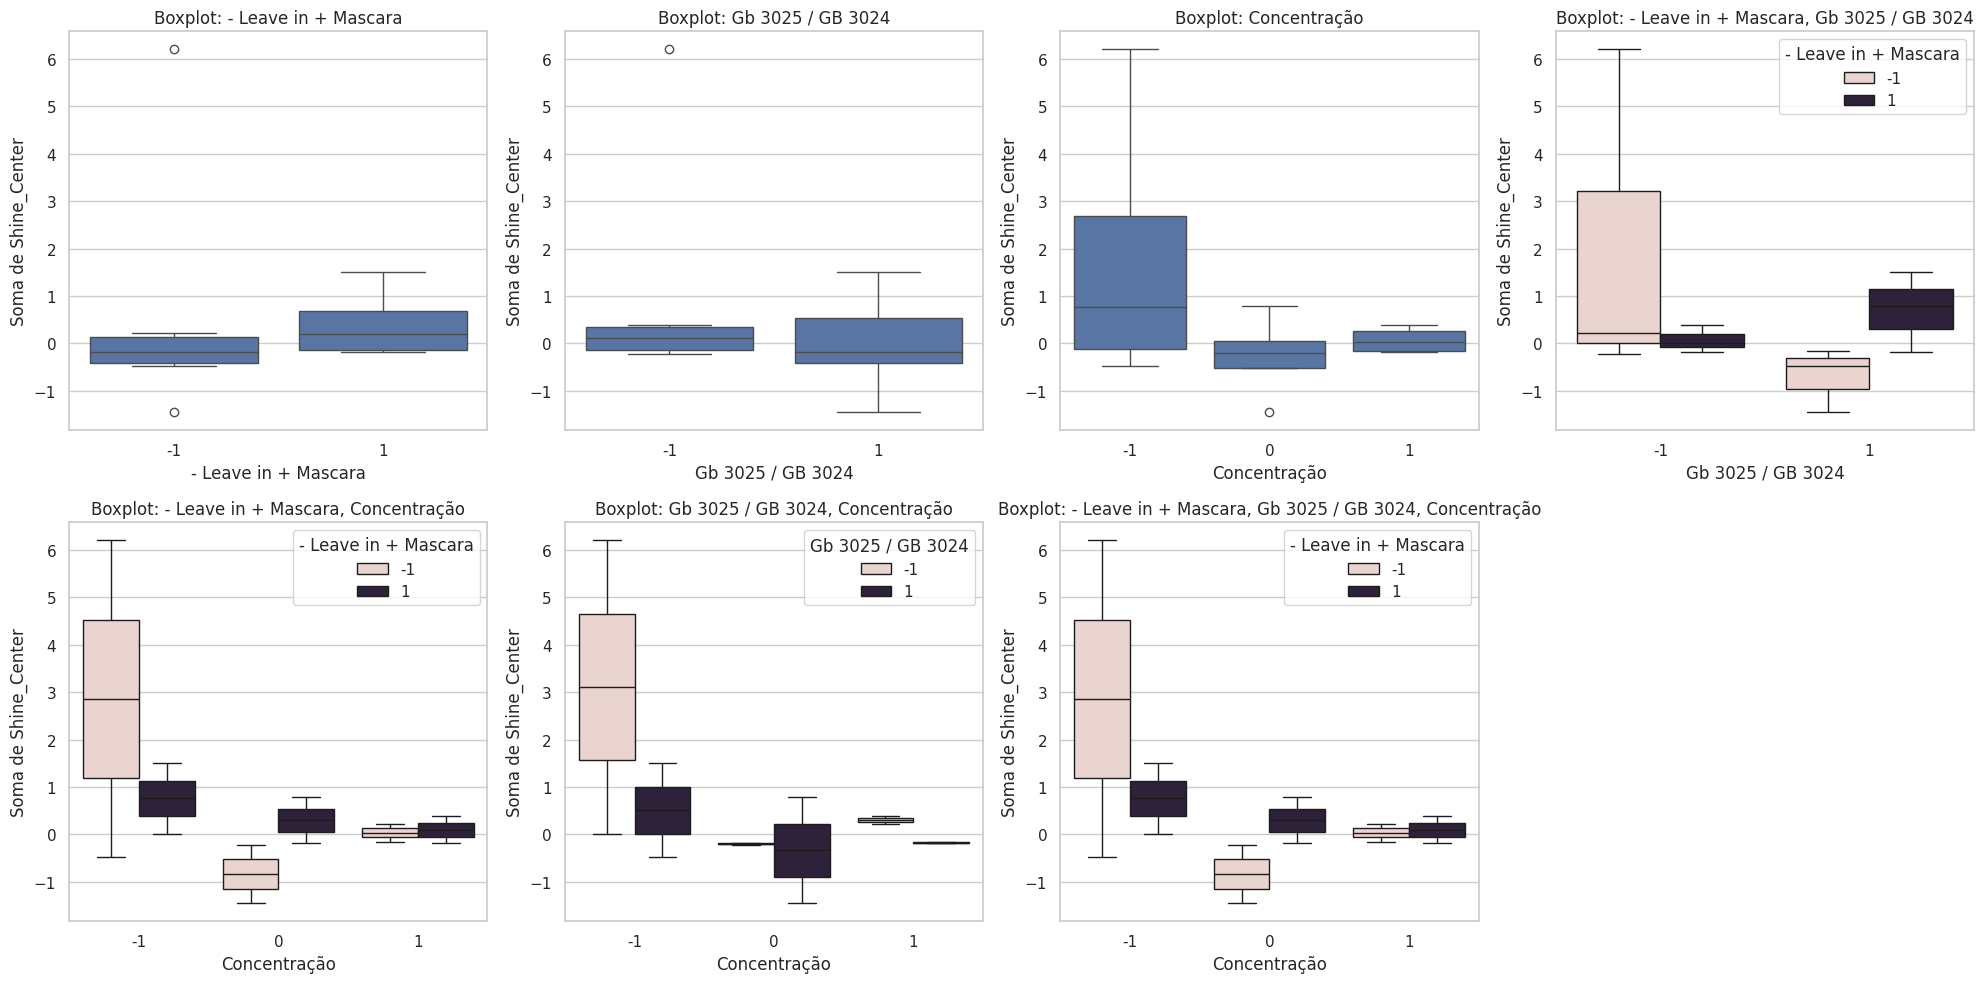

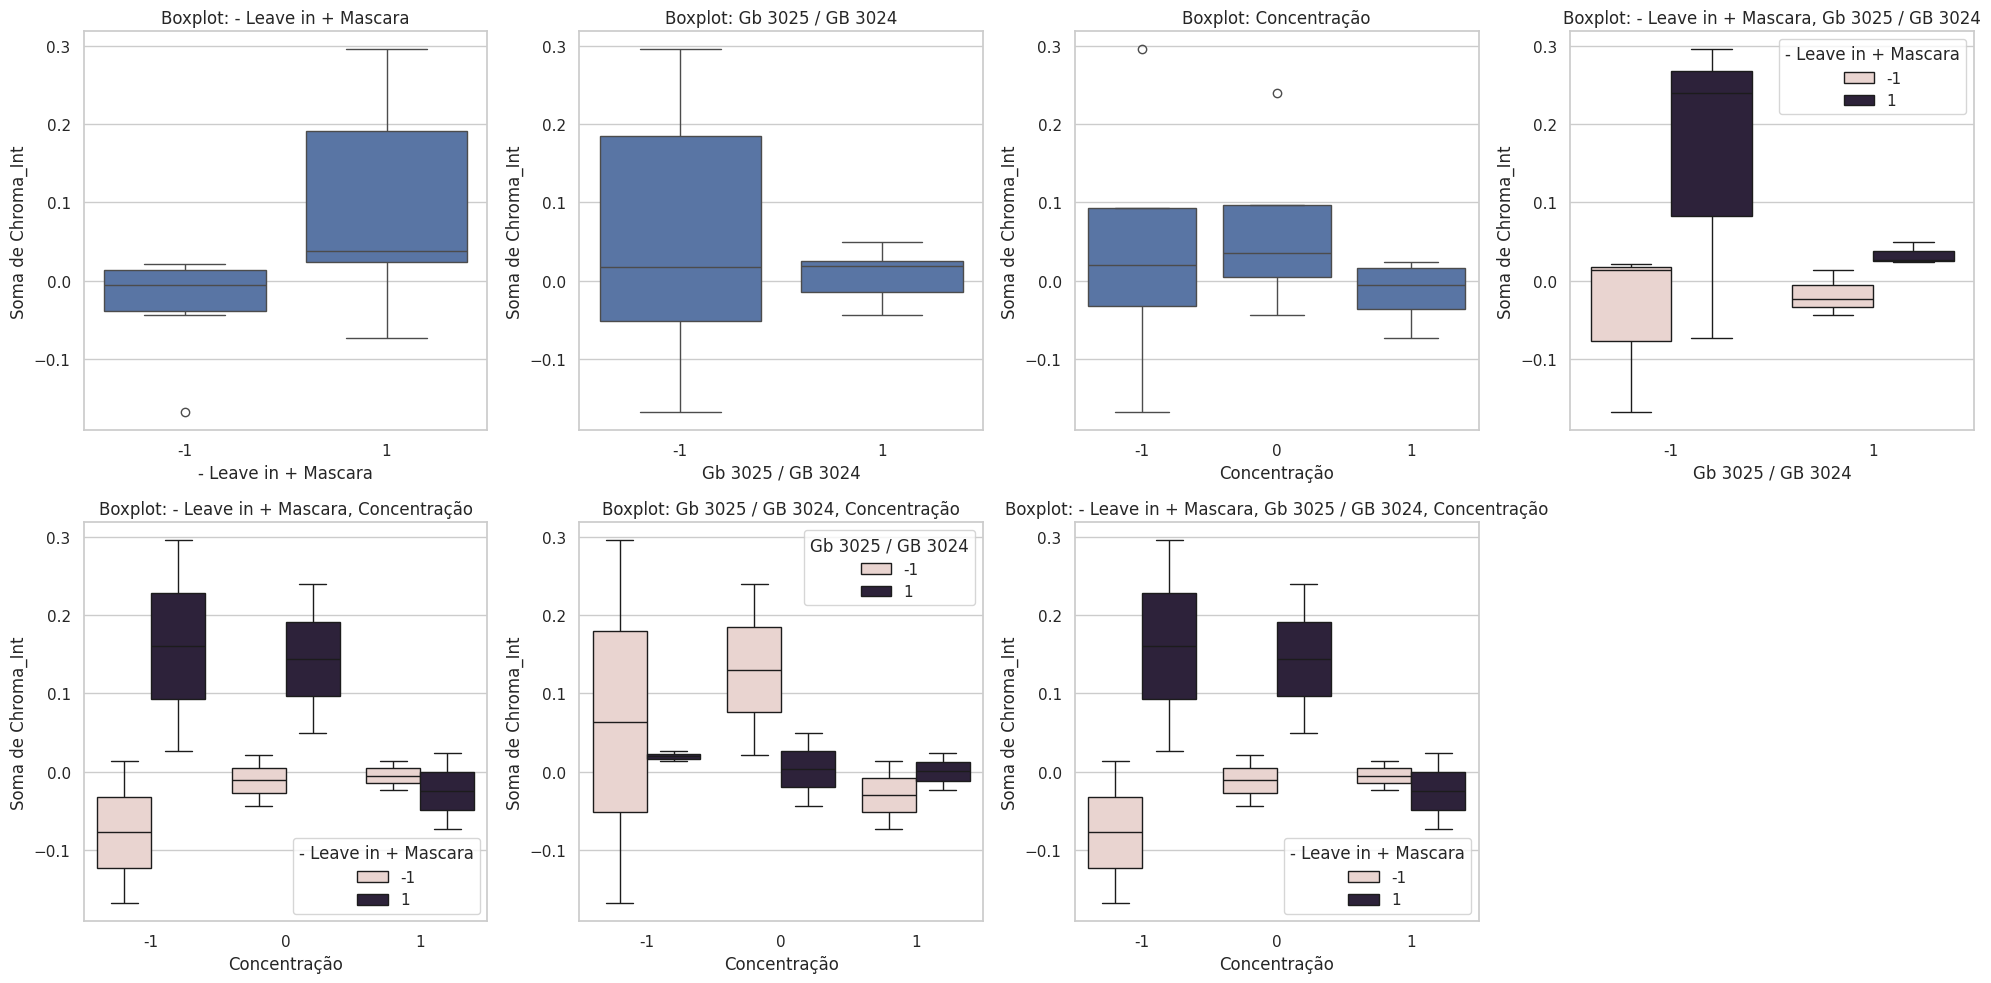

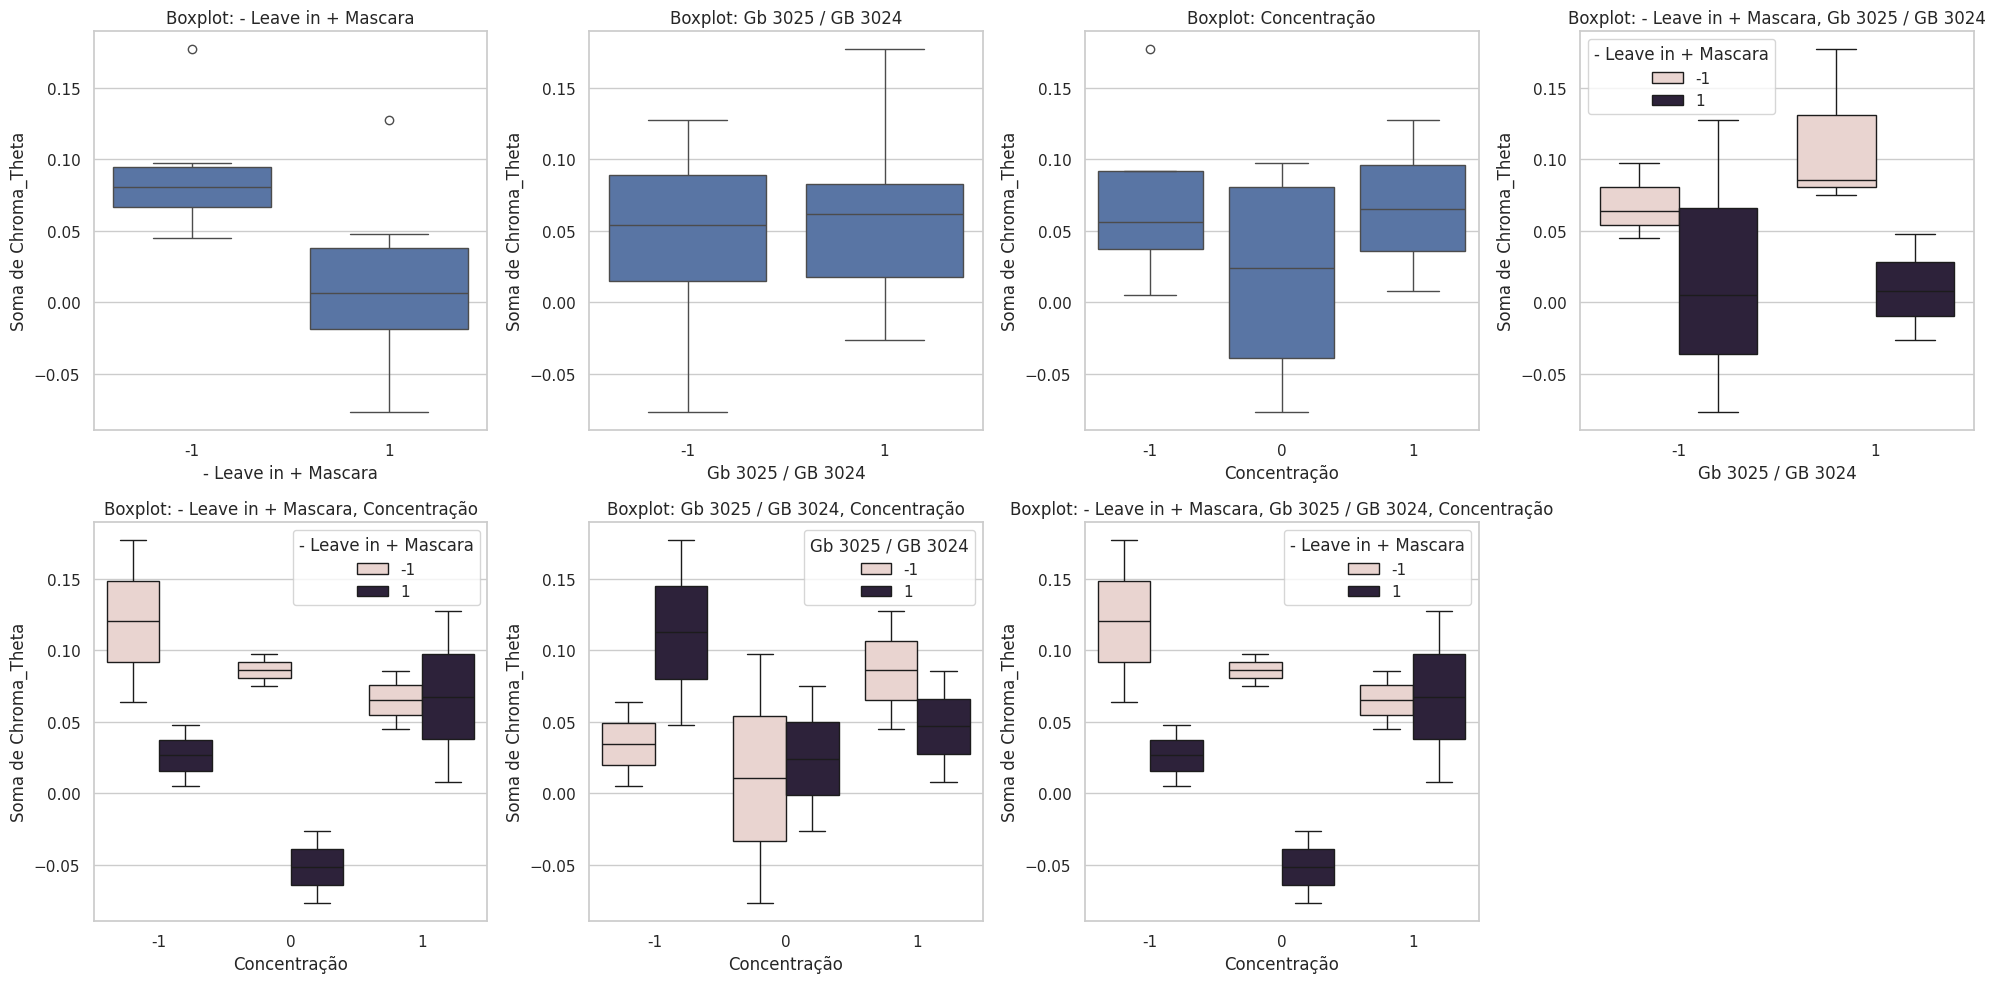

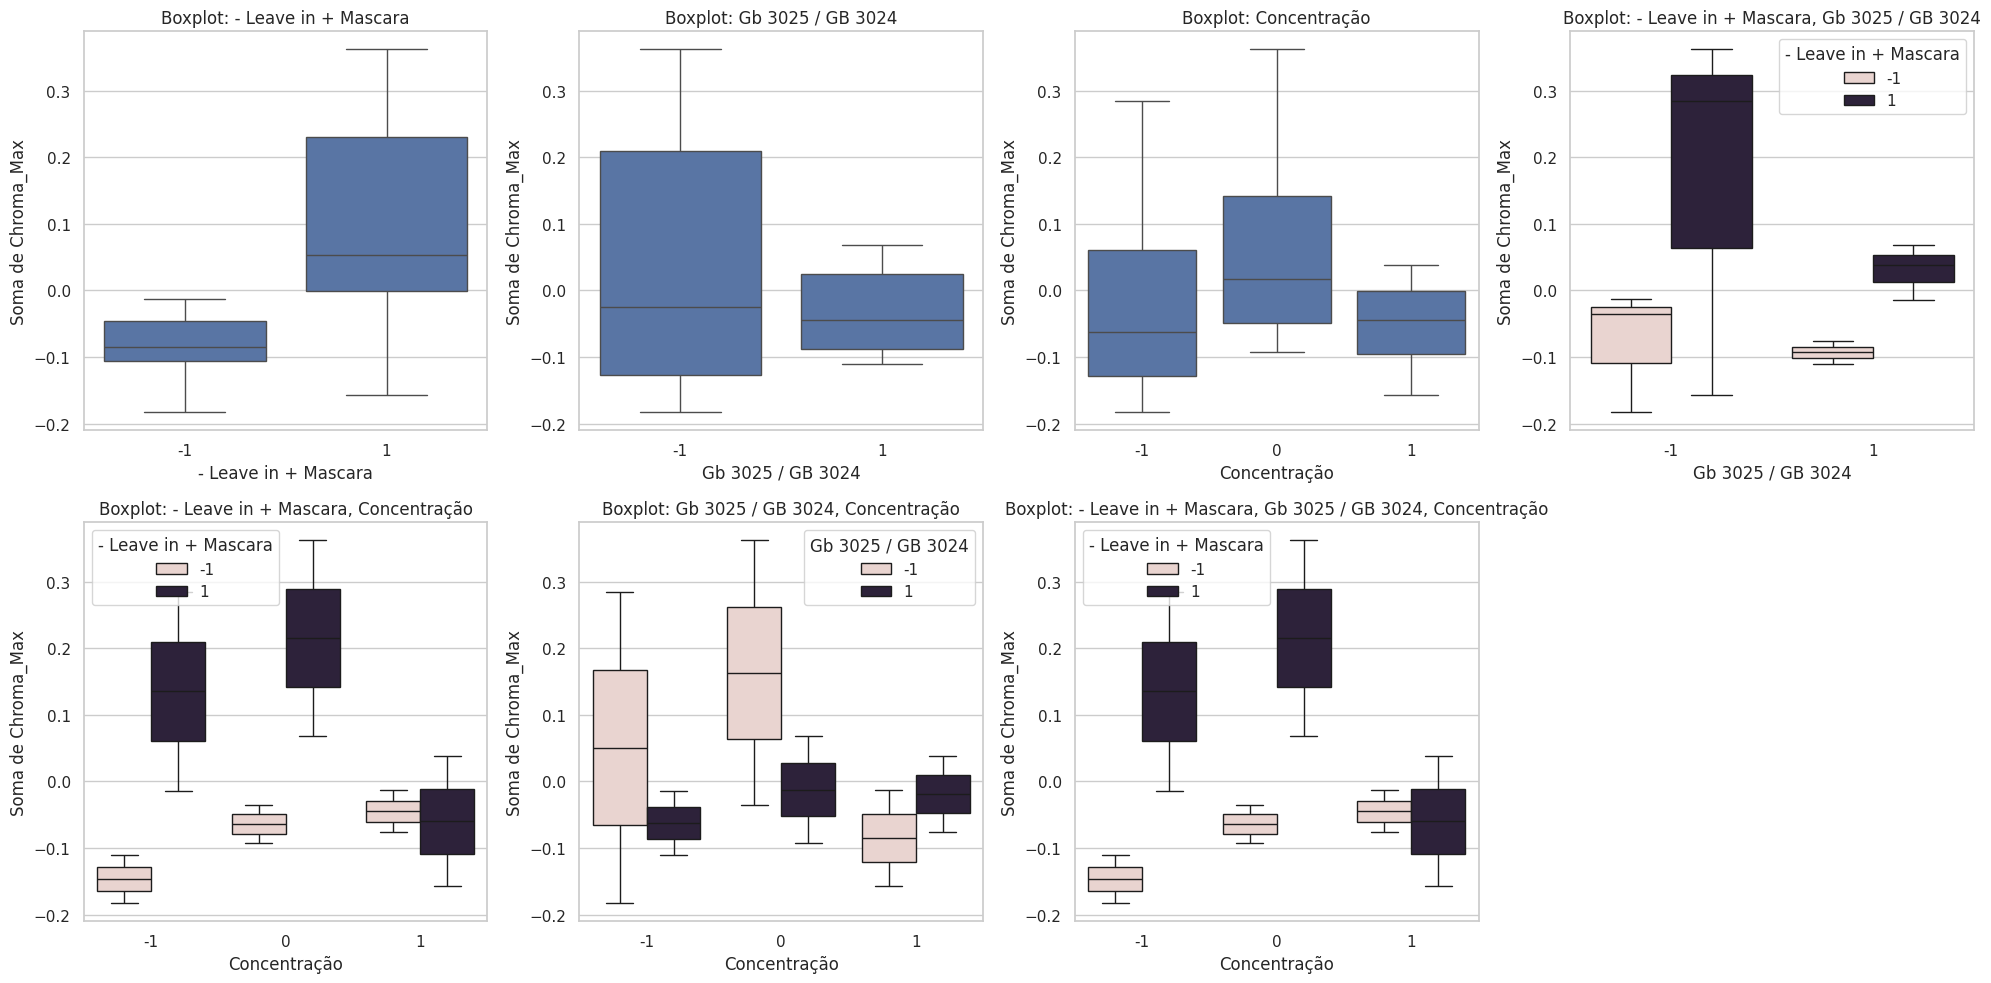

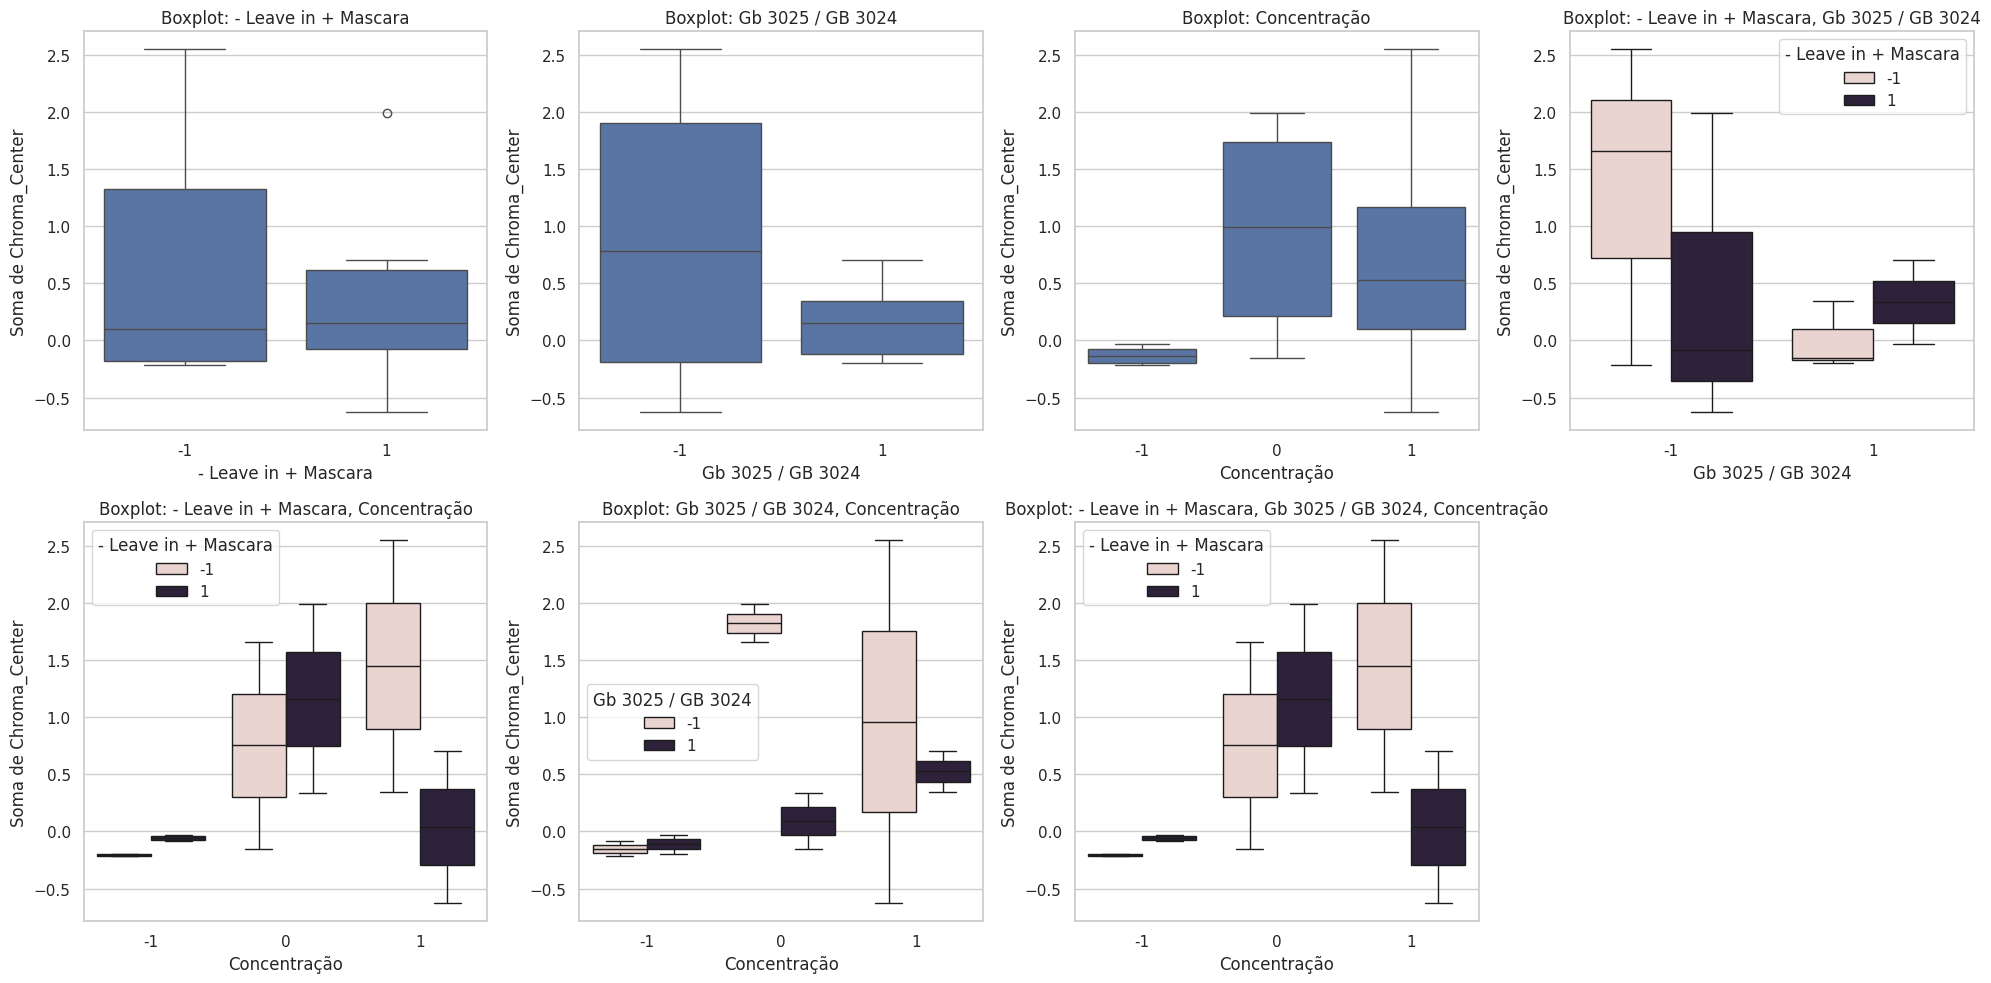

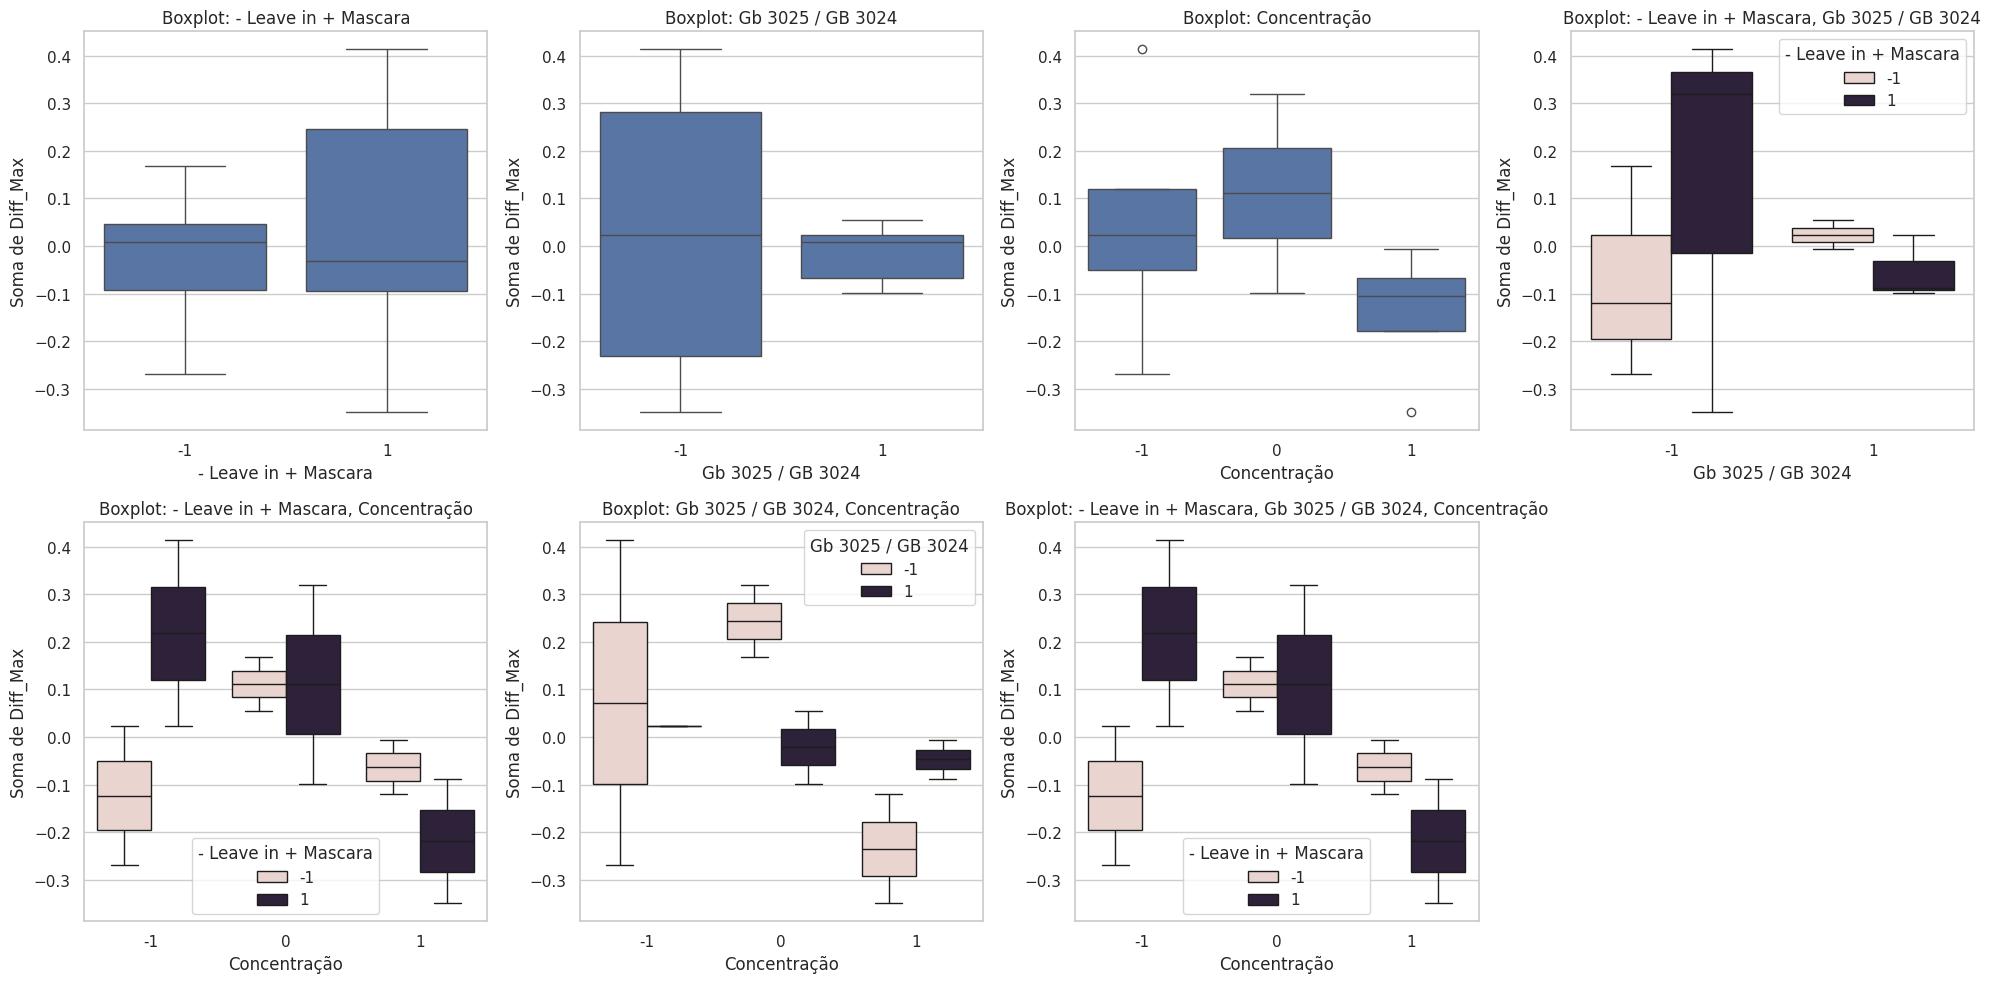

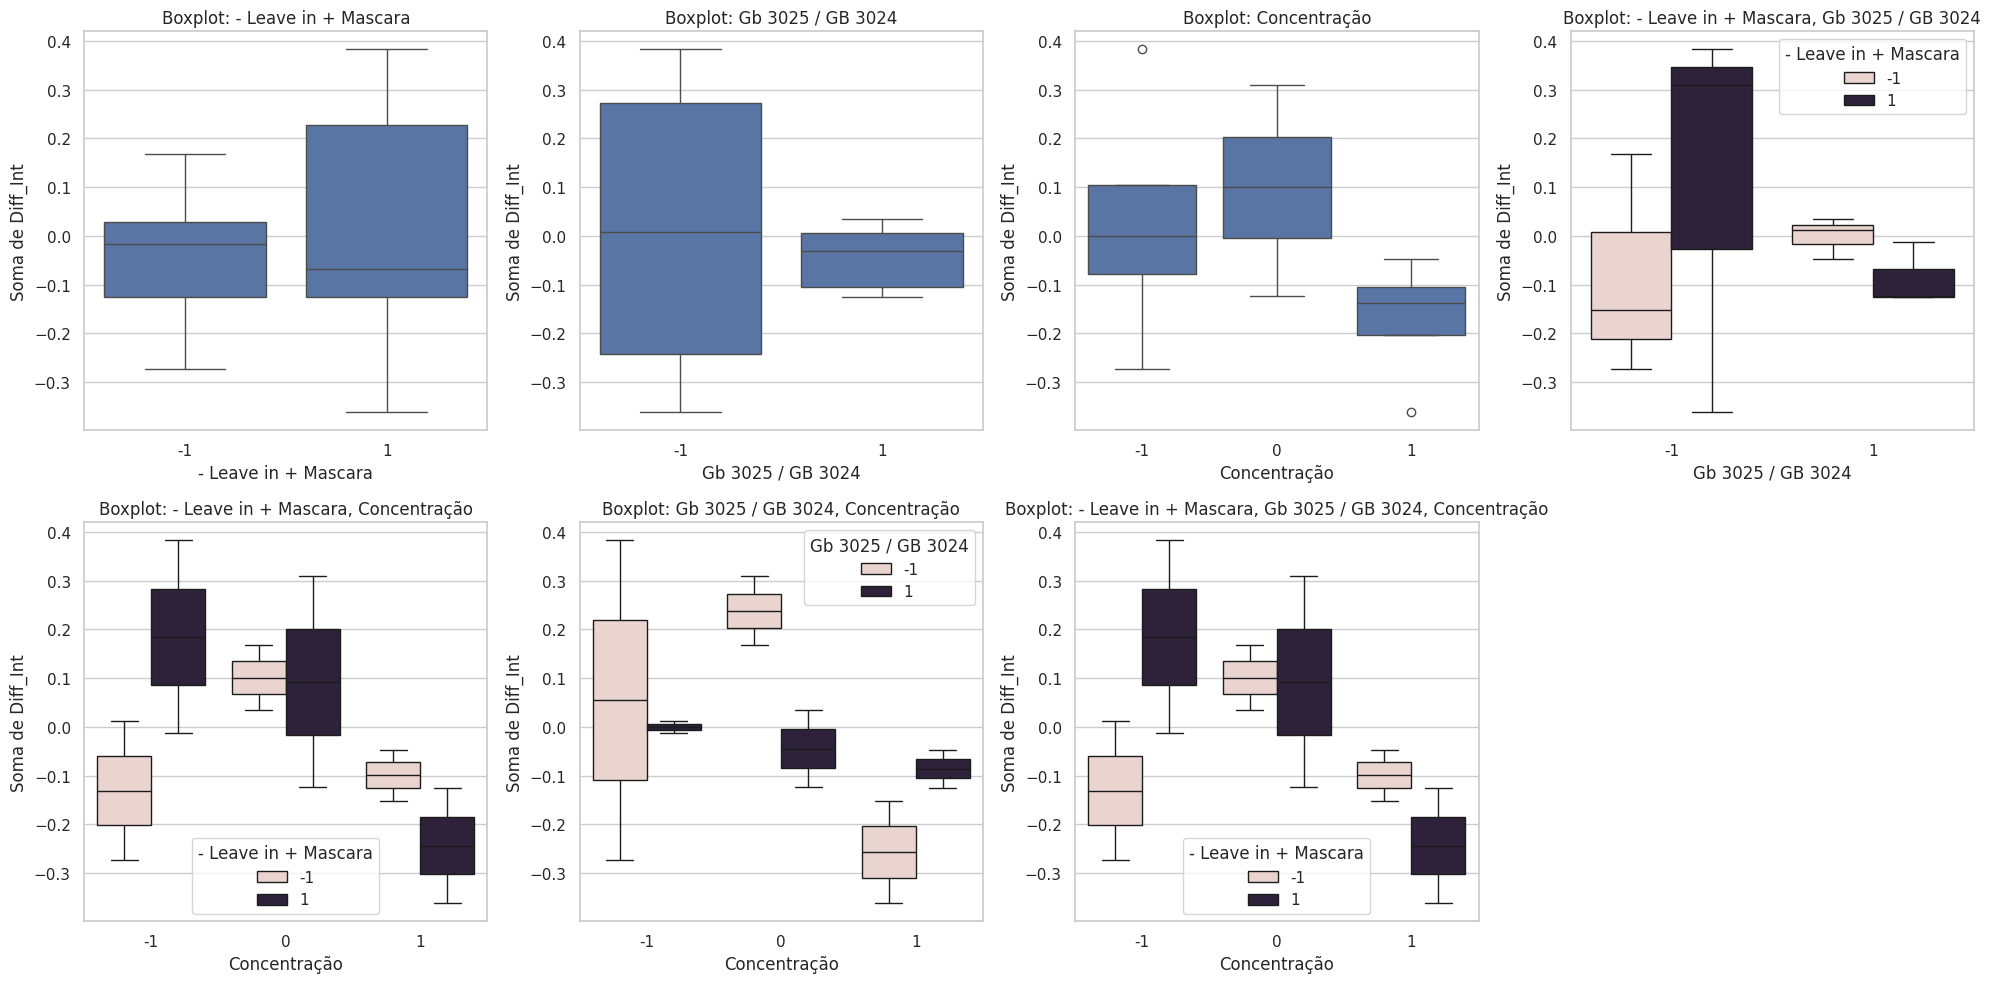

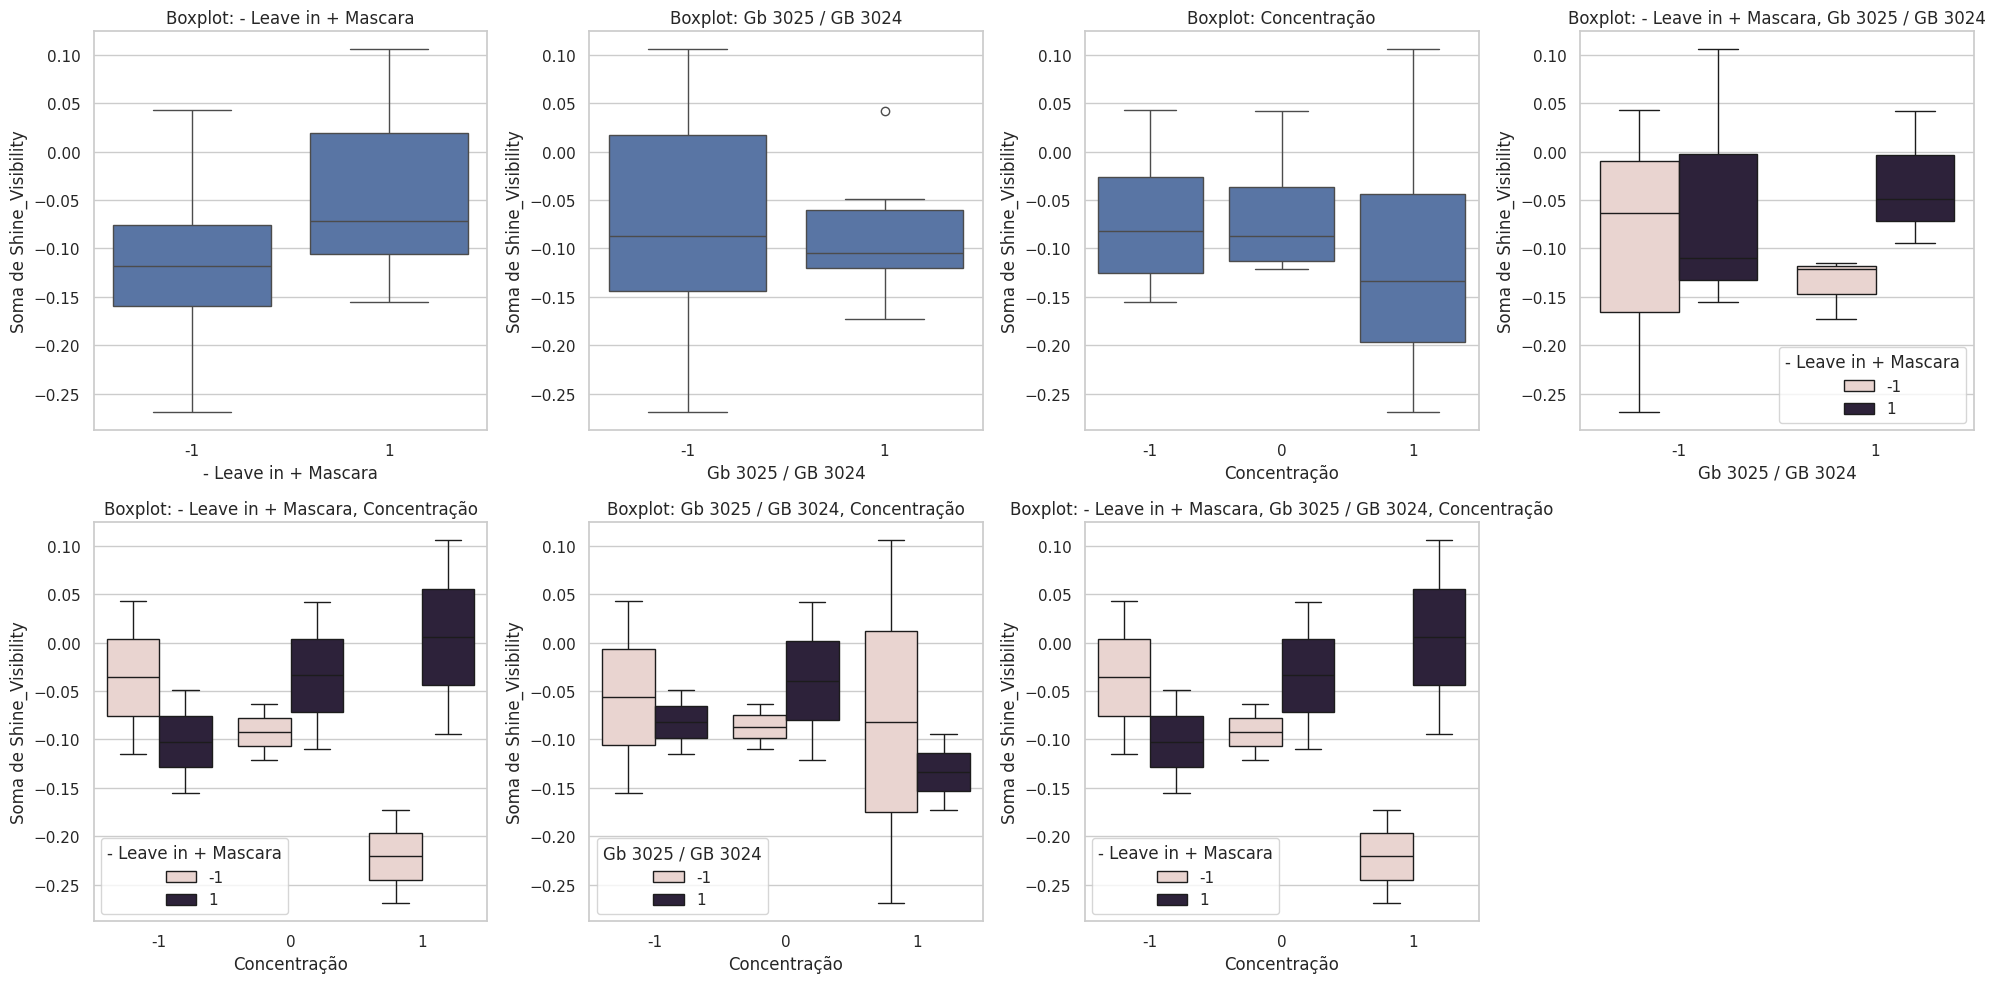

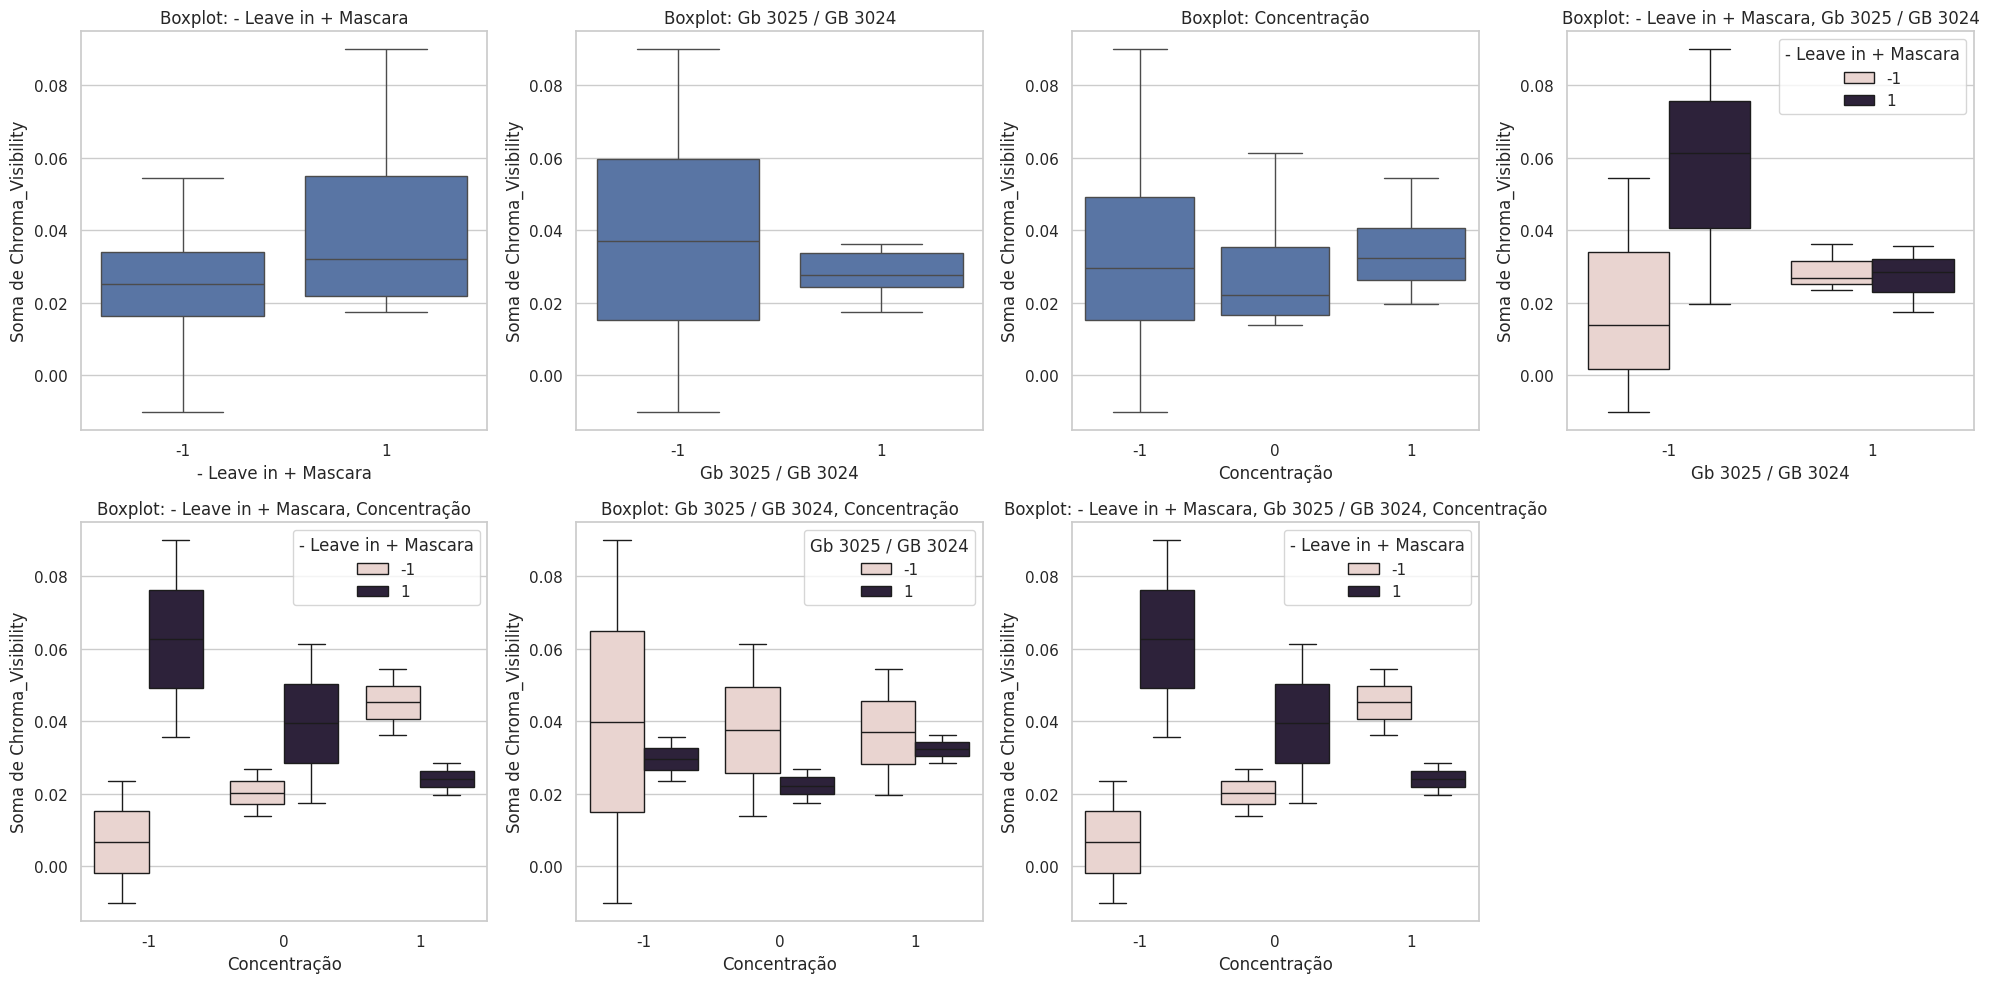

In [ ]:
for resposta in respostas:
    # Gerar todas as combinações possíveis de fatores
    fator_combinacoes = []
    for r in range(1, len(fatores) + 1):  # Combinações de 1 fator até n fatores
        fator_combinacoes.extend(combinations(fatores, r))

    # Configuração da grade de gráficos
    num_graficos = len(fator_combinacoes)
    colunas = 4  # Número de gráficos por linha
    linhas = (num_graficos + colunas - 1) // colunas  # Calcula o número de linhas necessárias

    fig, axes = plt.subplots(linhas, colunas, figsize=(20, 5 * linhas))
    axes = axes.flatten()  # Achata a grade para facilitar o acesso aos eixos

    # Loop para gerar gráficos para cada combinação de fatores
    for i, combinacao in enumerate(fator_combinacoes):
        ax = axes[i]
        combinacao = list(combinacao)

        # Boxplot para a combinação de fatores
        sns.boxplot(data=df, x=combinacao[-1], y=resposta, hue=combinacao[0] if len(combinacao) > 1 else None, ax=ax)
        ax.set_title(f"Boxplot: {', '.join(combinacao)}")
        ax.set_xlabel(combinacao[-1])
        ax.set_ylabel(resposta)

    # Remover eixos vazios (se o número de gráficos for menor que o número de subplots)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

ValueError: cannot insert Concentração, already exists

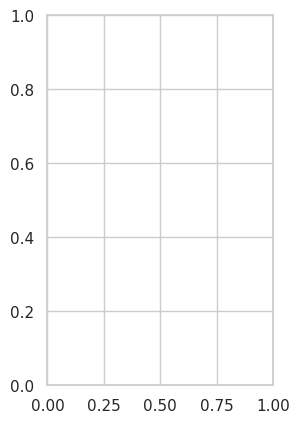

In [ ]:
    # Gráfico de barras com médias e desvios padrão
    plt.subplot(1, 2, 2)
    media_desvio = df.groupby(fatores + [fatores[-1]])[resposta].agg(['mean', 'std']).reset_index()
    sns.barplot(x=fatores[-1], y='mean', hue=fatores[0], data=media_desvio, palette='Set2', ci=None)
    plt.errorbar(
        x=np.arange(len(media_desvio)),
        y=media_desvio['mean'],
        yerr=media_desvio['std'],
        fmt='none',
        c='black',
        capsize=5
    )
    plt.title(f'Média e Desvio Padrão por Grupo ({resposta})')
    plt.xlabel(fatores[-1])
    plt.ylabel('Média da Resposta')

    plt.tight_layout()
    plt.show()



In [ ]:
# Função para interpretar significância estatística
def interpretar_significancia(p_valor):
    if p_valor < 0.05:
        return "Significativo no nível de 95%"
    elif p_valor < 0.10:
        return "Significativo no nível de 90%"
    elif p_valor < 0.30:
        return "Significativo no nível de 70%"
    else:
        return "Não significativo"

# Testes estatísticos
for resposta in respostas:
    print(f"\nTestes estatísticos para a resposta: {resposta}")

    # Teste ANOVA de um fator (último fator)
    print(f"\nTeste ANOVA de um fator ({fatores[-1]}):")
    unique_fator = df[fatores[-1]].unique()
    anova_result = f_oneway(
        *[df[df[fatores[-1]] == nivel][resposta] for nivel in unique_fator]
    )
    print(f"F-valor: {anova_result.statistic:.2f}, p-valor: {anova_result.pvalue:.4f}")
    print(f"Interpretação: {interpretar_significancia(anova_result.pvalue)}")

    # Teste ANOVA de dois fatores (primeiro e último fator)
    print(f"\nTeste ANOVA de dois fatores ({fatores[0]} e {fatores[-1]}):")
    anova_result_fator_1 = f_oneway(
        *[df[df[fatores[0]] == nivel][resposta] for nivel in df[fatores[0]].unique()]
    )
    anova_result_fator_2 = f_oneway(
        *[df[df[fatores[-1]] == nivel][resposta] for nivel in df[fatores[-1]].unique()]
    )
    print(f"F-valor ({fatores[0]}): {anova_result_fator_1.statistic:.2f}, p-valor: {anova_result_fator_1.pvalue:.4f}")
    print(f"Interpretação ({fatores[0]}): {interpretar_significancia(anova_result_fator_1.pvalue)}")
    print(f"F-valor ({fatores[-1]}): {anova_result_fator_2.statistic:.2f}, p-valor: {anova_result_fator_2.pvalue:.4f}")
    print(f"Interpretação ({fatores[-1]}): {interpretar_significancia(anova_result_fator_2.pvalue)}")


Testes estatísticos para a resposta: Soma de BNT

Teste ANOVA de um fator (Concentração):
F-valor: 0.36, p-valor: 0.7046
Interpretação: Não significativo

Teste ANOVA de dois fatores (- Leave in + Mascara e Concentração):
F-valor (- Leave in + Mascara): 2.33, p-valor: 0.1579
Interpretação (- Leave in + Mascara): Significativo no nível de 70%
F-valor (Concentração): 0.36, p-valor: 0.7046
Interpretação (Concentração): Não significativo

Testes estatísticos para a resposta: Soma de ReichRobbins

Teste ANOVA de um fator (Concentração):
F-valor: 0.89, p-valor: 0.4439
Interpretação: Não significativo

Teste ANOVA de dois fatores (- Leave in + Mascara e Concentração):
F-valor (- Leave in + Mascara): 1.96, p-valor: 0.1918
Interpretação (- Leave in + Mascara): Significativo no nível de 70%
F-valor (Concentração): 0.89, p-valor: 0.4439
Interpretação (Concentração): Não significativo

Testes estatísticos para a resposta: Soma de Guiolet

Teste ANOVA de um fator (Concentração):
F-valor: 1.97, p-v